# Unified measured neutron and gamma radiation field

This notebook combines the completed measured-neutron analysis from Notebook 4
and the completed measured-gamma analysis from Notebook 4.5. Its central
derived result is a **theory-assisted total AP effective-dose-rate estimate**
on the measurement-specific P1--P5 grid used by Notebook 3.

The calculation deliberately keeps the two measured components separate until
the final addition. Notebook 3 supplies component-specific conversion factors,

$$
C_n(P,d,h)=
\frac{\dot E_{\mathrm{AP},n}^{(N3)}(P,d,h)}
     {\dot H_{n,\mathrm{proxy}}^{(N3)}(P,d,h)},
$$

$$
C_\gamma(P,d,h)=
\frac{\dot E_{\mathrm{AP},\gamma}^{(N3)}(P,d,h)}
     {\dot H_{\gamma,\mathrm{proxy}}^{(N3)}(P,d,h)}.
$$

The measured indications are first converted component by component and then
interpolated independently onto the common Notebook 3 target grid:

$$
\widehat{\dot E}_{\mathrm{AP,tot}}
=
\widehat{\dot E}_{\mathrm{AP},n}
+
\widehat{\dot E}_{\mathrm{AP},\gamma}.
$$

This avoids the earlier zigzag artefact: neutron and gamma points are never
alternated in a single connected curve, and actual target heights remain
separate. The final quantity is model-assisted rather than a direct,
statistically independent total-dose measurement.


# 1) Setup and analysis conventions

The visual conventions match Notebooks 3--4.5:

- P1 blue, P2 orange, P3 green, P4 red, and P5 purple;
- increasing height is shown with progressively lighter shades;
- all dose-rate figures use a semi-logarithmic $y$ axis;
- horizontal position limits are shown as $\pm1$ cm;
- vertical bars or bands represent propagated $\pm1$ standard uncertainty;
- the derived total component is hot pink.

The common inclusive analysis intervals are $38$--$65$ cm and $85$--$113$ cm.
They select the measurements available for interpolation, while exact target
heights remain visible in every final curve.


In [1]:
# ============================================================
# 1) Setup and immutable analysis conventions
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, Patch

try:
    from IPython.display import display
except ImportError:
    def display(*objects):
        for object_to_display in objects:
            print(object_to_display)

BASE_DIR = Path.cwd().resolve()

OUTPUT_DIR = BASE_DIR / "N5_unified_measured_outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
METADATA_DIR = OUTPUT_DIR / "metadata"

for directory in (OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, METADATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

POSITION_SEQUENCE = ["P1", "P2", "P3", "P4", "P5"]
POSITION_ORDER = {
    position: index
    for index, position in enumerate(POSITION_SEQUENCE, start=1)
}

HEIGHT_INTERVAL_SEQUENCE = ["lower", "upper"]
HEIGHT_INTERVAL_ORDER = {"lower": 0, "upper": 1}
ANALYSIS_HEIGHT_INTERVALS_CM = {
    "lower": (38.0, 65.0),
    "upper": (85.0, 113.0),
}
ANALYSIS_HEIGHT_INTERVAL_LABELS = {
    "lower": "Lower height interval (38–65 cm)",
    "upper": "Upper height interval (85–113 cm)",
}

POSITION_COLORS = {
    "P1": "tab:blue",
    "P2": "tab:orange",
    "P3": "tab:green",
    "P4": "tab:red",
    "P5": "tab:purple",
}
TOTAL_COLOR = "hotpink"

NOMINAL_COORDINATE_DECIMALS = 3
ONE_SIDED_95_Z = 1.6448536269514722
DEFAULT_POSITION_LIMIT_CM = 1.0
DEFAULT_HEIGHT_LIMIT_CM = 1.0

FIGURE_SUPTITLE_FONTSIZE = 17
FIGURE_TITLE_FONTSIZE = 15
FIGURE_LABEL_FONTSIZE = 13
FIGURE_TICK_FONTSIZE = 11
FIGURE_LEGEND_FONTSIZE = 10.5
FIGURE_LEGEND_TITLE_FONTSIZE = 11.5

# Notebook 1_6 six-face broad-group sums are retained only as a qualitative
# energy-distribution audit. The actual factors below use Notebook 3's full
# energy-dependent ICRP-116 AP weighting.
N1_6_BROAD_ENERGY_FRACTIONS_PERCENT = {
    "neutron": {
        "thermal": 0.09122801,
        "epithermal_intermediate": 21.12094678,
        "fast": 78.78782521,
    },
    "gamma": {
        "low_energy": 0.79788166,
        "intermediate": 41.58099767,
        "high_energy": 57.62112066,
    },
}

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 190)
pd.set_option("display.max_colwidth", 150)
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": FIGURE_TITLE_FONTSIZE,
    "axes.labelsize": FIGURE_LABEL_FONTSIZE,
    "xtick.labelsize": FIGURE_TICK_FONTSIZE,
    "ytick.labelsize": FIGURE_TICK_FONTSIZE,
    "legend.fontsize": FIGURE_LEGEND_FONTSIZE,
})


def lighten_color(color, amount):
    base_rgb = np.asarray(to_rgb(color), dtype=float)
    return tuple((1.0 - amount) * base_rgb + amount * np.ones(3))


def assign_analysis_height_interval(height_cm):
    height_cm = float(height_cm)
    for interval, (lower_cm, upper_cm) in ANALYSIS_HEIGHT_INTERVALS_CM.items():
        if lower_cm <= height_cm <= upper_cm:
            return interval
    return pd.NA


def log_safe_yerr(mean, uncertainty):
    mean = np.asarray(mean, dtype=float)
    uncertainty = np.asarray(uncertainty, dtype=float)
    lower = np.minimum(
        uncertainty,
        np.maximum(mean * (1.0 - 1.0e-6), 0.0),
    )
    return np.vstack([lower, uncertainty])


print("Notebook 5 setup completed.")
print(f"Working directory: {BASE_DIR}")
print(f"Output directory:  {OUTPUT_DIR}")


Notebook 5 setup completed.
Working directory: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn
Output directory:  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs


# 2) Load and validate the four canonical input tables

Notebook 5 reads:

1. the final measured-neutron plotting table from Notebook 4;
2. the final measured-gamma summary from Notebook 4.5;
3. Notebook 3's physical neutron, photon, and total AP dose rates;
4. Notebook 3's response-labelled Studsvik and GCA proxy fields.

No raw CPS plot is reproduced here. The gamma input remains the calibrated,
background-corrected Cs-137-equivalent GCA indication from Notebook 4.5.


In [2]:
# ============================================================
# 2) Load and audit canonical measured and simulated inputs
# ============================================================

def first_existing_project_file(candidates, label):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.is_file():
            print(f"Using {label}: {candidate}")
            return candidate
    tried = "\n".join(f"  {Path(path)}" for path in candidates)
    raise FileNotFoundError(f"Could not find {label}. Tried:\n{tried}")


def require_columns(dataframe, columns, label):
    missing = [column for column in columns if column not in dataframe.columns]
    if missing:
        raise KeyError(
            f"{label} is missing required columns: {missing}. "
            f"Available columns: {dataframe.columns.tolist()}"
        )


neutron_input_path = first_existing_project_file(
    [
        BASE_DIR / "N4_measured_neutron_outputs" / "tables"
        / "08_measured_dose_rate_plotting_data.csv",
    ],
    "Notebook 4 measured-neutron table",
)
gamma_input_path = first_existing_project_file(
    [
        BASE_DIR / "N4_5_measured_gamma_outputs" / "tables"
        / "measured_gamma_scan_summary_final.csv",
    ],
    "Notebook 4.5 measured-gamma table",
)
n3_unified_input_path = first_existing_project_file(
    [
        BASE_DIR / "N3_simulated_unified_outputs" / "tables"
        / "unified_simulated_radiation_field_final.csv",
        BASE_DIR / "unified_simulated_radiation_field_final.csv",
    ],
    "Notebook 3 physical unified-dose table",
)
n3_proxy_input_path = first_existing_project_file(
    [
        BASE_DIR / "N3_simulated_unified_outputs" / "tables"
        / "simulated_instrument_equivalent_radiation_field_final.csv",
    ],
    "Notebook 3 response-labelled proxy table",
)

measured_neutron_raw_df = pd.read_csv(neutron_input_path)
measured_gamma_raw_df = pd.read_csv(gamma_input_path)
n3_unified_raw_df = pd.read_csv(n3_unified_input_path)
n3_proxy_raw_df = pd.read_csv(n3_proxy_input_path)

require_columns(
    measured_neutron_raw_df,
    [
        "position", "physical_point_id", "distance_cm", "height_cm",
        "detector_indicated_neutron_dose_equivalent_rate_uSv_h",
        "detector_indicated_neutron_dose_equivalent_rate_uncertainty_uSv_h",
        "geometry_x_cm", "geometry_y_cm", "geometry_z_cm",
    ],
    "Notebook 4 neutron input",
)
require_columns(
    measured_gamma_raw_df,
    [
        "position", "physical_point_id", "distance_cm", "height_cm",
        "detector_indicated_gamma_dose_rate_cs137_equivalent_uSv_h",
        "detector_indicated_gamma_dose_rate_cs137_equivalent_uncertainty_uSv_h",
        "geometry_x_cm", "geometry_y_cm", "geometry_z_cm",
    ],
    "Notebook 4.5 gamma input",
)
require_columns(
    n3_unified_raw_df,
    [
        "position", "distance_cm", "height_cm",
        "neutron_dose_rate [uSv/h]", "gamma_dose_rate [uSv/h]",
        "u_mc_neutron_dose_rate [uSv/h]",
        "u_mc_gamma_dose_rate [uSv/h]",
        "total_dose_rate [uSv/h]", "u_mc_total_dose_rate [uSv/h]",
    ],
    "Notebook 3 physical AP-dose input",
)
require_columns(
    n3_proxy_raw_df,
    [
        "position", "distance_cm", "height_cm",
        "simulated_2202d_equivalent_proxy [uSv/h]",
        "u_mc_simulated_2202d_equivalent_proxy [uSv/h]",
        "simulated_gca_cs137_equivalent_proxy [uSv/h]",
        "u_mc_simulated_gca_cs137_equivalent_proxy [uSv/h]",
    ],
    "Notebook 3 response-labelled proxy input",
)

input_audit_df = pd.DataFrame([
    {
        "input_role": "measured neutron component",
        "source_path": str(neutron_input_path),
        "rows": len(measured_neutron_raw_df),
        "columns": len(measured_neutron_raw_df.columns),
    },
    {
        "input_role": "measured gamma component",
        "source_path": str(gamma_input_path),
        "rows": len(measured_gamma_raw_df),
        "columns": len(measured_gamma_raw_df.columns),
    },
    {
        "input_role": "Notebook 3 physical AP components and target grid",
        "source_path": str(n3_unified_input_path),
        "rows": len(n3_unified_raw_df),
        "columns": len(n3_unified_raw_df.columns),
    },
    {
        "input_role": "Notebook 3 detector-proxy components",
        "source_path": str(n3_proxy_input_path),
        "rows": len(n3_proxy_raw_df),
        "columns": len(n3_proxy_raw_df.columns),
    },
])

display(input_audit_df)


Using Notebook 4 measured-neutron table: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N4_measured_neutron_outputs/tables/08_measured_dose_rate_plotting_data.csv
Using Notebook 4.5 measured-gamma table: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N4_5_measured_gamma_outputs/tables/measured_gamma_scan_summary_final.csv
Using Notebook 3 physical unified-dose table: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N3_simulated_unified_outputs/tables/unified_simulated_radiation_field_final.csv
Using Notebook 3 response-labelled proxy table: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N3_simulated_unified_outputs/tables/simulated_instrument_equivalent_radiation_field_final.csv


,input_role,source_path,rows,columns
0,measured neutron component,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N4_measured_neutron_outputs/tables/08_measured_dose_rate_plotting_data.csv,61,78
1,measured gamma component,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N4_5_measured_gamma_outputs/tables/measured_gamma_scan_summary_final.csv,45,75
2,Notebook 3 physical AP components and target grid,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N3_simulated_unified_outputs/tables/unified_simulated_radiation_field_final.csv,61,72
3,Notebook 3 detector-proxy components,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N3_simulated_unified_outputs/tables/simulated_instrument_equivalent_radiation_field_fin...,61,30


# 3) Standardize the measured detector components

The standardized tables retain the two distinct response references:

- the Studsvik moderator-centre reference for neutron measurements;
- the LND 712 active-centre reference for gamma measurements.

Measurement SEM and geometric limits remain separate. A gamma result not
exceeding the local background by $2\sigma$ is retained as a one-sided upper
limit rather than converted into an ordinary central curve point.


In [3]:
# ============================================================
# 3) Standardize measured neutron and gamma records
# ============================================================

def first_column(dataframe, candidates, label, required=True):
    for column in candidates:
        if column in dataframe.columns:
            return column
    if required:
        raise KeyError(
            f"Could not find {label}. Tried {candidates}. "
            f"Available columns: {dataframe.columns.tolist()}"
        )
    return None


def numeric_series(dataframe, candidates, label, required=True, default=np.nan):
    column = first_column(dataframe, candidates, label, required=required)
    if column is None:
        return pd.Series(default, index=dataframe.index, dtype=float), None
    return pd.to_numeric(dataframe[column], errors="coerce"), column


def boolean_series(dataframe, candidates, default=pd.NA):
    column = first_column(dataframe, candidates, "Boolean column", required=False)
    if column is None:
        return pd.Series(default, index=dataframe.index, dtype="boolean"), None
    values = dataframe[column]
    if pd.api.types.is_bool_dtype(values):
        return values.astype("boolean"), column
    normalized = values.astype(str).str.strip().str.lower().map({
        "true": True, "false": False, "1": True, "0": False,
        "yes": True, "no": False, "nan": pd.NA, "none": pd.NA, "": pd.NA,
    })
    return normalized.astype("boolean"), column


def canonical_position(series):
    extracted = series.astype(str).str.extract(r"(P[1-5])", expand=False)
    return extracted.fillna(series.astype(str).str.strip().str.upper())


def standardize_measurement(dataframe, radiation_type, source_path):
    result = pd.DataFrame(index=dataframe.index)
    result["radiation_type"] = radiation_type
    result["position"] = canonical_position(dataframe["position"])
    result["physical_point_id"] = dataframe["physical_point_id"].astype(str)

    for coordinate in ["distance_cm", "height_cm", "geometry_x_cm", "geometry_y_cm", "geometry_z_cm"]:
        result[coordinate] = pd.to_numeric(dataframe[coordinate], errors="coerce")

    if radiation_type == "neutron":
        rate_candidates = [
            "detector_indicated_neutron_dose_equivalent_rate_uSv_h",
            "net_mean_uSv_h",
        ]
        uncertainty_candidates = [
            "detector_indicated_neutron_dose_equivalent_rate_uncertainty_uSv_h",
            "net_uncertainty_uSv_h",
            "net_sem_effective_uSv_h",
        ]
        result["instrument_model"] = "Studsvik AE 2202 D"
        result["measurement_quantity"] = (
            "detector-indicated neutron dose-equivalent rate"
        )
        result["response_reference"] = (
            "nominal centre of the Studsvik cylindrical moderator"
        )
        result["instrument_orientation_deg"] = pd.to_numeric(
            dataframe.get("instrument_orientation_deg", 90.0), errors="coerce"
        )
        result["instrument_orientation_limit_deg"] = pd.to_numeric(
            dataframe.get("instrument_orientation_uncertainty_deg", 1.0),
            errors="coerce",
        )
    else:
        rate_candidates = [
            "detector_indicated_gamma_dose_rate_cs137_equivalent_uSv_h",
            "net_gamma_uSv_h",
        ]
        uncertainty_candidates = [
            "detector_indicated_gamma_dose_rate_cs137_equivalent_uncertainty_uSv_h",
            "net_gamma_uncertainty_uSv_h",
        ]
        result["instrument_model"] = "GCA-07W-DL with LND 712 GM tube"
        result["measurement_quantity"] = (
            "detector-indicated Cs-137-equivalent gamma dose rate"
        )
        result["response_reference"] = "LND 712 active-volume centre"
        result["instrument_orientation_deg"] = pd.to_numeric(
            dataframe.get("detector_axis_alignment_deg", 0.0), errors="coerce"
        )
        result["instrument_orientation_limit_deg"] = pd.to_numeric(
            dataframe.get("detector_axis_alignment_uncertainty_deg", 1.0),
            errors="coerce",
        )

    result["reported_rate_uSv_h"], rate_column = numeric_series(
        dataframe, rate_candidates, f"{radiation_type} indicated rate"
    )
    result["reported_rate_uncertainty_uSv_h"], uncertainty_column = numeric_series(
        dataframe, uncertainty_candidates, f"{radiation_type} indicated uncertainty"
    )
    result["above_background_2sigma"], significance_column = boolean_series(
        dataframe, ["above_background_2sigma"], default=True
    )
    result["horizontal_position_limit_cm"], position_limit_column = numeric_series(
        dataframe,
        ["horizontal_line_position_uncertainty_cm", "distance_uncertainty_cm"],
        "horizontal position limit",
        required=False,
        default=DEFAULT_POSITION_LIMIT_CM,
    )
    result["height_position_limit_cm"], height_limit_column = numeric_series(
        dataframe,
        ["height_uncertainty_cm"],
        "height position limit",
        required=False,
        default=DEFAULT_HEIGHT_LIMIT_CM,
    )

    result["horizontal_position_limit_cm"] = (
        result["horizontal_position_limit_cm"].fillna(DEFAULT_POSITION_LIMIT_CM)
    )
    result["height_position_limit_cm"] = (
        result["height_position_limit_cm"].fillna(DEFAULT_HEIGHT_LIMIT_CM)
    )
    result["analysis_height_interval"] = result["height_cm"].apply(
        assign_analysis_height_interval
    )
    result["analysis_height_interval_label"] = result[
        "analysis_height_interval"
    ].map(ANALYSIS_HEIGHT_INTERVAL_LABELS)
    result["source_table"] = str(source_path)
    result["source_rate_column"] = rate_column
    result["source_uncertainty_column"] = uncertainty_column
    result["source_significance_column"] = significance_column
    result["source_position_limit_column"] = position_limit_column
    result["source_height_limit_column"] = height_limit_column
    result["reported_relative_uncertainty_percent"] = np.where(
        result["reported_rate_uSv_h"].abs() > 0.0,
        100.0 * result["reported_rate_uncertainty_uSv_h"]
        / result["reported_rate_uSv_h"].abs(),
        np.nan,
    )
    return result


measured_neutron_component_df = standardize_measurement(
    measured_neutron_raw_df, "neutron", neutron_input_path
)
measured_gamma_component_df = standardize_measurement(
    measured_gamma_raw_df, "gamma", gamma_input_path
)

for component_df, label in [
    (measured_neutron_component_df, "standardized neutron input"),
    (measured_gamma_component_df, "standardized gamma input"),
]:
    if not component_df["position"].isin(POSITION_SEQUENCE).all():
        raise ValueError(f"{label} contains an unexpected P-position.")
    if component_df["analysis_height_interval"].isna().any():
        display(component_df.loc[
            component_df["analysis_height_interval"].isna(),
            ["position", "distance_cm", "height_cm", "physical_point_id"],
        ])
        raise ValueError(
            f"{label} contains measurements outside the selected height intervals."
        )
    numeric_columns = [
        "distance_cm", "height_cm", "geometry_x_cm", "geometry_y_cm",
        "geometry_z_cm", "reported_rate_uSv_h",
        "reported_rate_uncertainty_uSv_h",
    ]
    if not np.isfinite(component_df[numeric_columns].to_numpy(float)).all():
        raise ValueError(f"{label} contains non-finite core values.")
    if (component_df["reported_rate_uncertainty_uSv_h"] < 0.0).any():
        raise ValueError(f"{label} contains a negative uncertainty.")
    duplicate_key = component_df.duplicated(
        ["position", "distance_cm", "height_cm"], keep=False
    )
    if duplicate_key.any():
        display(component_df.loc[
            duplicate_key,
            ["position", "distance_cm", "height_cm", "physical_point_id"],
        ])
        raise ValueError(f"{label} contains duplicate nominal scan coordinates.")

measured_unified_long_df = pd.concat(
    [measured_neutron_component_df, measured_gamma_component_df],
    ignore_index=True,
    sort=False,
)
measured_unified_long_df["_position_order"] = (
    measured_unified_long_df["position"].map(POSITION_ORDER)
)
measured_unified_long_df["_interval_order"] = (
    measured_unified_long_df["analysis_height_interval"].map(HEIGHT_INTERVAL_ORDER)
)
measured_unified_long_df = (
    measured_unified_long_df
    .sort_values([
        "_position_order", "_interval_order", "height_cm", "distance_cm",
        "radiation_type",
    ])
    .drop(columns=["_position_order", "_interval_order"])
    .reset_index(drop=True)
)

measurement_coverage_summary_df = (
    measured_unified_long_df
    .groupby(
        ["position", "analysis_height_interval", "radiation_type"],
        dropna=False,
    )
    .agg(
        number_of_measurements=("physical_point_id", "size"),
        number_of_heights=("height_cm", "nunique"),
        minimum_height_cm=("height_cm", "min"),
        maximum_height_cm=("height_cm", "max"),
        minimum_distance_cm=("distance_cm", "min"),
        maximum_distance_cm=("distance_cm", "max"),
    )
    .reset_index()
)

print("Measured detector components standardized.")
print(f"Neutron points: {len(measured_neutron_component_df)}")
print(f"Gamma points:   {len(measured_gamma_component_df)}")
display(measurement_coverage_summary_df)


Measured detector components standardized.
Neutron points: 61
Gamma points:   45


,position,analysis_height_interval,radiation_type,number_of_measurements,number_of_heights,minimum_height_cm,maximum_height_cm,minimum_distance_cm,maximum_distance_cm
0,P1,lower,gamma,15,4,38.0,50.0,6.0,420.0
1,P1,lower,neutron,8,1,42.0,42.0,0.0,420.0
2,P1,upper,neutron,8,1,85.0,85.0,0.0,420.0
3,P2,lower,gamma,7,1,65.0,65.0,2.0,420.0
4,P2,lower,neutron,8,2,55.0,65.0,2.0,420.0
5,P2,upper,gamma,5,2,85.0,98.0,176.0,400.0
6,P2,upper,neutron,10,1,85.0,85.0,0.0,321.0
7,P3,lower,gamma,8,3,45.0,65.0,5.0,320.0
8,P3,lower,neutron,8,1,45.0,45.0,0.0,300.0
9,P3,upper,gamma,1,1,88.0,88.0,176.0,176.0


# 4) Construct the shared target grid and geometry

The target grid preserves Notebook 3's exact P1--P5 target heights. Its
distance coordinates are the union of Notebook 3 distances and the measured
neutron/gamma distances in the same P-position and height interval. This makes
all measured distance support available without joining unlike particles or
unlike heights. Geometry at an added distance is reconstructed from Notebook
3's measurement-specific coordinate model and is marked explicitly in the
exported table.

The common Studsvik reference centre is used for the AP component sum.
Notebook 3's displaced LND 712 active-centre coordinates are retained
separately for the spatial coverage figure.

The spatial plot shows both measured response references in the same visual
style as the earlier geometry figures, including direction colours, source
centre, position limits, orientation conventions, and P1--P5 endpoint labels.


In [4]:
# ============================================================
# 4) Shared target grid and geometry tables
# ============================================================

TARGET_KEY = ["position", "distance_cm", "height_cm"]

n3_target_columns = [
    "point_name", "position", "distance_cm", "height_cm",
    "common_dose_x_cm", "common_dose_y_cm", "common_dose_z_cm",
]
for optional_column in [
    "gamma_flux_x_cm", "gamma_flux_y_cm", "gamma_flux_z_cm",
]:
    if optional_column in n3_unified_raw_df.columns:
        n3_target_columns.append(optional_column)

require_columns(
    n3_unified_raw_df,
    [
        "point_name", "common_dose_x_cm", "common_dose_y_cm",
        "common_dose_z_cm",
    ],
    "Notebook 3 target-grid input",
)

notebook3_target_grid_df = n3_unified_raw_df[n3_target_columns].copy()
notebook3_target_grid_df["position"] = canonical_position(
    notebook3_target_grid_df["position"]
)
for column in [
    "distance_cm", "height_cm", "common_dose_x_cm", "common_dose_y_cm",
    "common_dose_z_cm", "gamma_flux_x_cm", "gamma_flux_y_cm",
    "gamma_flux_z_cm",
]:
    if column in notebook3_target_grid_df.columns:
        notebook3_target_grid_df[column] = pd.to_numeric(
            notebook3_target_grid_df[column], errors="coerce"
        )

notebook3_target_grid_df["analysis_height_interval"] = (
    notebook3_target_grid_df["height_cm"].apply(
        assign_analysis_height_interval
    )
)
notebook3_target_grid_df["analysis_height_interval_label"] = notebook3_target_grid_df[
    "analysis_height_interval"
].map(ANALYSIS_HEIGHT_INTERVAL_LABELS)
notebook3_target_grid_df = notebook3_target_grid_df.loc[
    notebook3_target_grid_df["analysis_height_interval"].notna()
].copy()

if notebook3_target_grid_df.duplicated(TARGET_KEY).any():
    raise ValueError("Notebook 3 target grid contains duplicate nominal points.")
if not np.isfinite(notebook3_target_grid_df[
    ["distance_cm", "height_cm", "common_dose_x_cm", "common_dose_y_cm", "common_dose_z_cm"]
].to_numpy(float)).all():
    raise ValueError("Notebook 3 target grid contains non-finite coordinates.")

if not all(
    column in notebook3_target_grid_df.columns
    for column in ["gamma_flux_x_cm", "gamma_flux_y_cm", "gamma_flux_z_cm"]
):
    notebook3_target_grid_df["gamma_flux_x_cm"] = notebook3_target_grid_df[
        "common_dose_x_cm"
    ]
    notebook3_target_grid_df["gamma_flux_y_cm"] = notebook3_target_grid_df[
        "common_dose_y_cm"
    ]
    notebook3_target_grid_df["gamma_flux_z_cm"] = notebook3_target_grid_df[
        "common_dose_z_cm"
    ]

notebook3_target_grid_df["target_grid_origin"] = "Notebook 3 target point"
notebook3_target_grid_df["geometry_reconstruction_mode"] = (
    "original Notebook 3 geometry"
)


def reconstruct_notebook3_geometry(position, distance_cm, height_cm, column):
    """Fit the position-specific Notebook 3 coordinate plane in d and h."""
    reference = notebook3_target_grid_df.loc[
        notebook3_target_grid_df["position"].eq(position),
        ["distance_cm", "height_cm", column],
    ].dropna()
    if reference.empty:
        return np.nan
    if len(reference) == 1:
        return float(reference[column].iloc[0])
    design = np.column_stack([
        np.ones(len(reference), dtype=float),
        reference["distance_cm"].to_numpy(float),
        reference["height_cm"].to_numpy(float),
    ])
    coefficients, *_ = np.linalg.lstsq(
        design,
        reference[column].to_numpy(float),
        rcond=None,
    )
    return float(
        np.array([1.0, float(distance_cm), float(height_cm)]) @ coefficients
    )


target_grid_rows = []
for (position, interval, height_cm), reference_curve in (
    notebook3_target_grid_df.groupby(
        ["position", "analysis_height_interval", "height_cm"],
        sort=True,
    )
):
    measured_distances = measured_unified_long_df.loc[
        measured_unified_long_df["position"].eq(position)
        & measured_unified_long_df["analysis_height_interval"].eq(interval),
        "distance_cm",
    ].dropna().to_numpy(float)
    target_distances = np.unique(np.concatenate([
        reference_curve["distance_cm"].to_numpy(float),
        measured_distances,
    ]))

    for distance_cm in target_distances:
        exact = reference_curve.loc[
            np.isclose(
                reference_curve["distance_cm"].to_numpy(float),
                float(distance_cm),
                rtol=0.0,
                atol=10.0 ** (-NOMINAL_COORDINATE_DECIMALS),
            )
        ]
        if not exact.empty:
            target_grid_rows.append(exact.iloc[0].to_dict())
            continue

        added = reference_curve.iloc[0].to_dict()
        added["point_name"] = (
            f"N5_{position}_x{float(distance_cm):g}_h{float(height_cm):g}"
        )
        added["distance_cm"] = float(distance_cm)
        added["height_cm"] = float(height_cm)
        for coordinate_column in [
            "common_dose_x_cm", "common_dose_y_cm", "common_dose_z_cm",
            "gamma_flux_x_cm", "gamma_flux_y_cm", "gamma_flux_z_cm",
        ]:
            added[coordinate_column] = reconstruct_notebook3_geometry(
                position,
                float(distance_cm),
                float(height_cm),
                coordinate_column,
            )
        added["target_grid_origin"] = (
            "measured distance added to Notebook 3 target height"
        )
        added["geometry_reconstruction_mode"] = (
            "position-specific least-squares Notebook 3 coordinate plane"
        )
        target_grid_rows.append(added)

target_grid_df = pd.DataFrame(target_grid_rows)
target_grid_df = target_grid_df.drop_duplicates(TARGET_KEY).copy()

target_grid_df["_position_order"] = target_grid_df["position"].map(POSITION_ORDER)
target_grid_df["_interval_order"] = target_grid_df[
    "analysis_height_interval"
].map(HEIGHT_INTERVAL_ORDER)
target_grid_df = (
    target_grid_df
    .sort_values(["_position_order", "_interval_order", "height_cm", "distance_cm"])
    .drop(columns=["_position_order", "_interval_order"])
    .reset_index(drop=True)
)

target_grid_summary_df = (
    target_grid_df
    .groupby(["position", "analysis_height_interval"], dropna=False)
    .agg(
        number_of_target_points=("point_name", "size"),
        original_notebook3_points=(
            "target_grid_origin",
            lambda series: int(series.eq("Notebook 3 target point").sum()),
        ),
        measurement_supported_added_points=(
            "target_grid_origin",
            lambda series: int(series.ne("Notebook 3 target point").sum()),
        ),
        number_of_target_heights=("height_cm", "nunique"),
        target_heights_cm=(
            "height_cm",
            lambda series: ", ".join(f"{value:g}" for value in np.sort(series.unique())),
        ),
        minimum_distance_cm=("distance_cm", "min"),
        maximum_distance_cm=("distance_cm", "max"),
    )
    .reset_index()
)

print(f"Common target-grid points: {len(target_grid_df)}")
display(target_grid_summary_df)


Common target-grid points: 81


,position,analysis_height_interval,number_of_target_points,original_notebook3_points,measurement_supported_added_points,number_of_target_heights,target_heights_cm,minimum_distance_cm,maximum_distance_cm
0,P1,lower,20,8,12,1,42,0.0,420.0
1,P1,upper,9,9,0,1,85,0.0,420.0
2,P2,lower,7,7,0,1,55,2.0,420.0
3,P2,upper,12,10,2,1,85,0.0,400.0
4,P3,lower,9,8,1,1,45,0.0,320.0
5,P3,upper,10,10,0,1,85,0.0,400.0
6,P4,lower,8,4,4,2,"42, 45",0.0,85.0
7,P4,upper,2,1,1,1,113,138.0,152.0
8,P5,lower,2,2,0,1,45,0.0,6.0
9,P5,upper,2,2,0,1,85,0.0,6.0


# 5) Build component-specific theoretical conversion fields

Notebook 3 supplies the full spectral weighting of each particle type with
ICRP Publication 116 fluence-to-effective-dose coefficients for AP irradiation.
Notebook 1_6 indicates qualitatively that the leakage is dominated by fast
neutrons and intermediate/high-energy photons; those broad particle-rate
fractions are **not** used numerically as dose weights.

The factors below convert like with like:

$$
C_n=\frac{\text{Notebook 3 neutron AP component}}
          {\text{Notebook 3 Studsvik-labelled neutron proxy}},
$$

$$
C_\gamma=\frac{\text{Notebook 3 photon AP component}}
               {\text{Notebook 3 GCA Cs-137-equivalent proxy}}.
$$

Unlike the rejected total/proxy construction, neither component is promoted
individually to an estimate of the entire radiation field.


In [5]:
# ============================================================
# 5) Component-specific Notebook 3 conversion factors
# ============================================================

n3_physical_df = n3_unified_raw_df[
    TARGET_KEY
    + [
        "neutron_dose_rate [uSv/h]",
        "u_mc_neutron_dose_rate [uSv/h]",
        "gamma_dose_rate [uSv/h]",
        "u_mc_gamma_dose_rate [uSv/h]",
        "total_dose_rate [uSv/h]",
        "u_mc_total_dose_rate [uSv/h]",
    ]
].copy()
n3_proxy_df = n3_proxy_raw_df[
    TARGET_KEY
    + [
        "simulated_2202d_equivalent_proxy [uSv/h]",
        "u_mc_simulated_2202d_equivalent_proxy [uSv/h]",
        "simulated_gca_cs137_equivalent_proxy [uSv/h]",
        "u_mc_simulated_gca_cs137_equivalent_proxy [uSv/h]",
    ]
].copy()

for dataframe in [n3_physical_df, n3_proxy_df]:
    dataframe["position"] = canonical_position(dataframe["position"])
    for column in ["distance_cm", "height_cm"]:
        dataframe[column] = pd.to_numeric(dataframe[column], errors="coerce")

if n3_physical_df.duplicated(TARGET_KEY).any():
    raise ValueError("Notebook 3 physical table contains duplicate target points.")
if n3_proxy_df.duplicated(TARGET_KEY).any():
    raise ValueError("Notebook 3 proxy table contains duplicate target points.")

theory_conversion_df = n3_physical_df.merge(
    n3_proxy_df,
    on=TARGET_KEY,
    how="inner",
    validate="one_to_one",
)
if len(theory_conversion_df) != len(n3_physical_df):
    raise ValueError("Notebook 3 physical and proxy supports are not identical.")

theory_conversion_df["analysis_height_interval"] = theory_conversion_df[
    "height_cm"
].apply(assign_analysis_height_interval)
theory_conversion_df = theory_conversion_df.loc[
    theory_conversion_df["analysis_height_interval"].notna()
].copy()


def ratio_with_zero_covariance(
    numerator, u_numerator, denominator, u_denominator
):
    numerator = np.asarray(numerator, dtype=float)
    u_numerator = np.asarray(u_numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    u_denominator = np.asarray(u_denominator, dtype=float)
    ratio = np.divide(
        numerator,
        denominator,
        out=np.full_like(numerator, np.nan),
        where=denominator > 0.0,
    )
    relative_variance = (
        np.divide(
            u_numerator, numerator,
            out=np.full_like(numerator, np.nan), where=numerator > 0.0,
        ) ** 2
        + np.divide(
            u_denominator, denominator,
            out=np.full_like(denominator, np.nan), where=denominator > 0.0,
        ) ** 2
    )
    return ratio, ratio * np.sqrt(relative_variance)


neutron_factor, u_neutron_factor = ratio_with_zero_covariance(
    theory_conversion_df["neutron_dose_rate [uSv/h]"],
    theory_conversion_df["u_mc_neutron_dose_rate [uSv/h]"],
    theory_conversion_df["simulated_2202d_equivalent_proxy [uSv/h]"],
    theory_conversion_df["u_mc_simulated_2202d_equivalent_proxy [uSv/h]"],
)
gamma_factor, u_gamma_factor = ratio_with_zero_covariance(
    theory_conversion_df["gamma_dose_rate [uSv/h]"],
    theory_conversion_df["u_mc_gamma_dose_rate [uSv/h]"],
    theory_conversion_df["simulated_gca_cs137_equivalent_proxy [uSv/h]"],
    theory_conversion_df["u_mc_simulated_gca_cs137_equivalent_proxy [uSv/h]"],
)

theory_conversion_df["neutron_component_conversion_factor"] = neutron_factor
theory_conversion_df["u_mc_neutron_component_conversion_factor"] = u_neutron_factor
theory_conversion_df["gamma_component_conversion_factor"] = gamma_factor
theory_conversion_df["u_mc_gamma_component_conversion_factor"] = u_gamma_factor
theory_conversion_df["theory_neutron_ap_fraction"] = (
    theory_conversion_df["neutron_dose_rate [uSv/h]"]
    / theory_conversion_df["total_dose_rate [uSv/h]"]
)
theory_conversion_df["theory_gamma_ap_fraction"] = (
    theory_conversion_df["gamma_dose_rate [uSv/h]"]
    / theory_conversion_df["total_dose_rate [uSv/h]"]
)

required_factor_columns = [
    "neutron_component_conversion_factor",
    "u_mc_neutron_component_conversion_factor",
    "gamma_component_conversion_factor",
    "u_mc_gamma_component_conversion_factor",
]
if not np.isfinite(theory_conversion_df[required_factor_columns].to_numpy(float)).all():
    raise ValueError("One or more component-specific theoretical factors are invalid.")
if (theory_conversion_df[[
    "neutron_component_conversion_factor",
    "gamma_component_conversion_factor",
]] <= 0.0).any().any():
    raise ValueError("Component-specific theoretical factors must be positive.")

fraction_sum = (
    theory_conversion_df["theory_neutron_ap_fraction"]
    + theory_conversion_df["theory_gamma_ap_fraction"]
)
if not np.allclose(fraction_sum, 1.0, rtol=1.0e-9, atol=1.0e-12):
    raise ValueError("Notebook 3 neutron and gamma AP fractions do not sum to one.")

conversion_factor_summary_df = (
    theory_conversion_df
    .groupby(["position", "analysis_height_interval"], dropna=False)
    .agg(
        number_of_theory_points=("distance_cm", "size"),
        minimum_neutron_factor=("neutron_component_conversion_factor", "min"),
        median_neutron_factor=("neutron_component_conversion_factor", "median"),
        maximum_neutron_factor=("neutron_component_conversion_factor", "max"),
        minimum_gamma_factor=("gamma_component_conversion_factor", "min"),
        median_gamma_factor=("gamma_component_conversion_factor", "median"),
        maximum_gamma_factor=("gamma_component_conversion_factor", "max"),
        median_neutron_ap_fraction=("theory_neutron_ap_fraction", "median"),
        median_gamma_ap_fraction=("theory_gamma_ap_fraction", "median"),
    )
    .reset_index()
)

n1_6_energy_group_audit_df = pd.DataFrame([
    {
        "particle": particle,
        "broad_energy_group": energy_group,
        "six_face_particle_rate_fraction_percent": fraction,
        "use_in_notebook_5": "qualitative energy-distribution cross-check only",
    }
    for particle, groups in N1_6_BROAD_ENERGY_FRACTIONS_PERCENT.items()
    for energy_group, fraction in groups.items()
])

print("Component-specific conversion factors created.")
display(conversion_factor_summary_df)
display(n1_6_energy_group_audit_df)


Component-specific conversion factors created.


,position,analysis_height_interval,number_of_theory_points,minimum_neutron_factor,median_neutron_factor,maximum_neutron_factor,minimum_gamma_factor,median_gamma_factor,maximum_gamma_factor,median_neutron_ap_fraction,median_gamma_ap_fraction
0,P1,lower,8,1.0,1.0,1.0,0.765532,1.421082,3.904714,0.992397,0.007603
1,P1,upper,9,1.0,1.0,1.0,1.278436,1.993415,3.222524,0.994323,0.005677
2,P2,lower,7,1.0,1.0,1.0,0.335427,0.963512,3.011722,0.999108,0.000892
3,P2,upper,10,1.0,1.0,1.0,0.317838,1.511257,5.796788,0.998768,0.001232
4,P3,lower,8,1.0,1.0,1.0,0.269307,1.006398,1.502237,0.999338,0.000662
5,P3,upper,10,1.0,1.0,1.0,0.836609,1.080140,3.606487,0.998692,0.001308
6,P4,lower,4,1.0,1.0,1.0,1.255409,1.579693,1.868836,0.999553,0.000447
7,P4,upper,1,1.0,1.0,1.0,1.122700,1.122700,1.122700,0.999594,0.000406
8,P5,lower,2,1.0,1.0,1.0,1.056725,1.121196,1.185668,0.998948,0.001052
9,P5,upper,2,1.0,1.0,1.0,1.497645,1.717084,1.936524,0.997170,0.002830


,particle,broad_energy_group,six_face_particle_rate_fraction_percent,use_in_notebook_5
0,neutron,thermal,0.091228,qualitative energy-distribution cross-check only
1,neutron,epithermal_intermediate,21.120947,qualitative energy-distribution cross-check only
2,neutron,fast,78.787825,qualitative energy-distribution cross-check only
3,gamma,low_energy,0.797882,qualitative energy-distribution cross-check only
4,gamma,intermediate,41.580998,qualitative energy-distribution cross-check only
5,gamma,high_energy,57.621121,qualitative energy-distribution cross-check only


# 6) Interpolate each measured component independently

For every Notebook 3 target point, the measured neutron and gamma fields are
interpolated independently within the same P-position and selected height
interval. The interpolation is performed in two stages:

1. log-linear interpolation with distance along each actual measured-height
   curve;
2. linear interpolation between those distance-interpolated values in height.

Only targets inside the measured component curves' distance support are
accepted; measured neutron or gamma fields are never extrapolated. For a
P-position and interval containing only one measured height, that curve
represents the interval and the height mismatch is recorded explicitly.

The Notebook 3 conversion field is a theoretical interval model. If a measured
height or distance lies just outside its discrete tabulated nodes, the nearest
factor at the same P-position and height interval is used and flagged as an
endpoint-representative factor. Gamma upper-limit points are excluded from
central interpolation.


In [6]:
# ============================================================
# 6) Scale measured components and interpolate to the common target grid
# ============================================================

def log_interpolate_positive(target, xp, fp, allow_endpoint_clipping=False):
    xp = np.asarray(xp, dtype=float)
    fp = np.asarray(fp, dtype=float)
    valid = np.isfinite(xp) & np.isfinite(fp) & (fp > 0.0)
    xp = xp[valid]
    fp = fp[valid]
    if xp.size == 0:
        return np.nan
    order = np.argsort(xp)
    xp = xp[order]
    fp = fp[order]
    if target < xp[0]:
        return float(fp[0]) if allow_endpoint_clipping else np.nan
    if target > xp[-1]:
        return float(fp[-1]) if allow_endpoint_clipping else np.nan
    if xp.size == 1:
        return (
            float(fp[0])
            if allow_endpoint_clipping or np.isclose(target, xp[0])
            else np.nan
        )
    return float(np.exp(np.interp(target, xp, np.log(fp))))


def interpolate_theory_value(position, interval, distance_cm, height_cm, column):
    theory_group = theory_conversion_df.loc[
        theory_conversion_df["position"].eq(position)
        & theory_conversion_df["analysis_height_interval"].eq(interval)
    ]
    predictions = []
    for theory_height, height_group in theory_group.groupby("height_cm", sort=True):
        value = log_interpolate_positive(
            distance_cm,
            height_group["distance_cm"],
            height_group[column],
            allow_endpoint_clipping=True,
        )
        if np.isfinite(value):
            predictions.append((float(theory_height), value))
    if not predictions:
        return np.nan
    predictions.sort(key=lambda item: item[0])
    heights = np.array([item[0] for item in predictions], dtype=float)
    values = np.array([item[1] for item in predictions], dtype=float)
    if heights.size == 1:
        return float(values[0])
    return float(np.interp(height_cm, heights, values))


scaled_component_rows = []
for measurement in measured_unified_long_df.itertuples(index=False):
    if measurement.radiation_type == "neutron":
        factor_column = "neutron_component_conversion_factor"
        factor_u_column = "u_mc_neutron_component_conversion_factor"
    else:
        factor_column = "gamma_component_conversion_factor"
        factor_u_column = "u_mc_gamma_component_conversion_factor"

    theory_support = theory_conversion_df.loc[
        theory_conversion_df["position"].eq(measurement.position)
        & theory_conversion_df["analysis_height_interval"].eq(
            measurement.analysis_height_interval
        )
    ]
    theory_distance_clipped = bool(
        not theory_support.empty
        and (
            float(measurement.distance_cm)
            < float(theory_support["distance_cm"].min())
            or float(measurement.distance_cm)
            > float(theory_support["distance_cm"].max())
        )
    )
    theory_height_clipped = bool(
        not theory_support.empty
        and (
            float(measurement.height_cm)
            < float(theory_support["height_cm"].min())
            or float(measurement.height_cm)
            > float(theory_support["height_cm"].max())
        )
    )

    factor = interpolate_theory_value(
        measurement.position,
        measurement.analysis_height_interval,
        float(measurement.distance_cm),
        float(measurement.height_cm),
        factor_column,
    )
    u_factor = interpolate_theory_value(
        measurement.position,
        measurement.analysis_height_interval,
        float(measurement.distance_cm),
        float(measurement.height_cm),
        factor_u_column,
    )
    factor_available = np.isfinite(factor) and factor > 0.0
    central_measurement = (
        measurement.radiation_type == "neutron"
        or bool(
            measurement.above_background_2sigma
            if pd.notna(measurement.above_background_2sigma)
            else False
        )
    )

    measured_rate = float(measurement.reported_rate_uSv_h)
    u_measured_rate = float(measurement.reported_rate_uncertainty_uSv_h)
    component_ap = measured_rate * factor if factor_available else np.nan
    u_measurement_scaled = (
        abs(factor) * u_measured_rate if factor_available else np.nan
    )
    u_theory_scaled = (
        abs(measured_rate) * u_factor
        if factor_available and np.isfinite(u_factor) and u_factor >= 0.0
        else np.nan
    )
    u_component_ap = (
        np.hypot(u_measurement_scaled, u_theory_scaled)
        if np.isfinite(u_measurement_scaled) and np.isfinite(u_theory_scaled)
        else np.nan
    )
    upper_indication = max(
        measured_rate + ONE_SIDED_95_Z * u_measured_rate, 0.0
    )
    component_upper = (
        upper_indication * factor if factor_available else np.nan
    )

    scaled_component_rows.append({
        **measurement._asdict(),
        "component_conversion_factor": factor,
        "u_mc_component_conversion_factor": u_factor,
        "component_ap_dose_rate_uSv_h": component_ap,
        "u_component_ap_dose_rate_uSv_h": u_component_ap,
        "u_scaled_measurement_uSv_h": u_measurement_scaled,
        "u_scaled_notebook3_mc_uSv_h": u_theory_scaled,
        "component_ap_95_upper_uSv_h": component_upper,
        "central_interpolation_eligible": bool(
            central_measurement
            and np.isfinite(component_ap)
            and component_ap > 0.0
            and np.isfinite(u_component_ap)
            and u_component_ap >= 0.0
        ),
        "gamma_upper_limit_only": bool(
            measurement.radiation_type == "gamma" and not central_measurement
        ),
        "factor_available": bool(factor_available),
        "theory_factor_distance_endpoint_representative": theory_distance_clipped,
        "theory_factor_height_endpoint_representative": theory_height_clipped,
        "theory_factor_interpolation_status": (
            "endpoint-representative within same P and height interval"
            if theory_distance_clipped or theory_height_clipped
            else "interpolated within Notebook 3 factor support"
        ),
    })

scaled_measured_components_df = pd.DataFrame(scaled_component_rows)


def interpolate_measured_surface(
    measured_group,
    target_distance_cm,
    target_height_cm,
    value_column,
):
    predictions = []
    distance_support_rows = []
    for measured_height, height_group in measured_group.groupby(
        "height_cm", sort=True
    ):
        curve = height_group.sort_values("distance_cm")
        minimum_distance = float(curve["distance_cm"].min())
        maximum_distance = float(curve["distance_cm"].max())
        if not (minimum_distance <= target_distance_cm <= maximum_distance):
            continue
        value = log_interpolate_positive(
            target_distance_cm,
            curve["distance_cm"],
            curve[value_column],
        )
        if np.isfinite(value):
            predictions.append((float(measured_height), value))
            distance_support_rows.append((minimum_distance, maximum_distance))

    if not predictions:
        return {
            "value": np.nan,
            "available": False,
            "height_mode": "unavailable",
            "minimum_support_height_cm": np.nan,
            "maximum_support_height_cm": np.nan,
            "minimum_support_distance_cm": np.nan,
            "maximum_support_distance_cm": np.nan,
        }

    predictions.sort(key=lambda item: item[0])
    heights = np.array([item[0] for item in predictions], dtype=float)
    values = np.array([item[1] for item in predictions], dtype=float)
    minimum_distance = min(item[0] for item in distance_support_rows)
    maximum_distance = max(item[1] for item in distance_support_rows)

    if heights.size == 1:
        return {
            "value": float(values[0]),
            "available": True,
            "height_mode": "single measured height represents interval",
            "minimum_support_height_cm": float(heights[0]),
            "maximum_support_height_cm": float(heights[0]),
            "minimum_support_distance_cm": float(minimum_distance),
            "maximum_support_distance_cm": float(maximum_distance),
        }

    if target_height_cm < heights[0] or target_height_cm > heights[-1]:
        return {
            "value": np.nan,
            "available": False,
            "height_mode": "target outside bracketing measured heights",
            "minimum_support_height_cm": float(heights[0]),
            "maximum_support_height_cm": float(heights[-1]),
            "minimum_support_distance_cm": float(minimum_distance),
            "maximum_support_distance_cm": float(maximum_distance),
        }

    return {
        "value": float(np.interp(target_height_cm, heights, values)),
        "available": True,
        "height_mode": "interpolated between measured heights",
        "minimum_support_height_cm": float(heights[0]),
        "maximum_support_height_cm": float(heights[-1]),
        "minimum_support_distance_cm": float(minimum_distance),
        "maximum_support_distance_cm": float(maximum_distance),
    }


target_rows = []
for target in target_grid_df.itertuples(index=False):
    component_results = {}
    for radiation_type in ["neutron", "gamma"]:
        measured_group = scaled_measured_components_df.loc[
            scaled_measured_components_df["position"].eq(target.position)
            & scaled_measured_components_df["analysis_height_interval"].eq(
                target.analysis_height_interval
            )
            & scaled_measured_components_df["radiation_type"].eq(radiation_type)
            & scaled_measured_components_df["central_interpolation_eligible"]
        ]
        value_result = interpolate_measured_surface(
            measured_group,
            float(target.distance_cm),
            float(target.height_cm),
            "component_ap_dose_rate_uSv_h",
        )
        uncertainty_result = interpolate_measured_surface(
            measured_group,
            float(target.distance_cm),
            float(target.height_cm),
            "u_component_ap_dose_rate_uSv_h",
        )
        component_results[radiation_type] = {
            **value_result,
            "uncertainty": uncertainty_result["value"],
            "uncertainty_available": uncertainty_result["available"],
        }

    neutron_result = component_results["neutron"]
    gamma_result = component_results["gamma"]
    neutron_available = bool(
        neutron_result["available"]
        and neutron_result["uncertainty_available"]
        and neutron_result["value"] > 0.0
    )
    gamma_available = bool(
        gamma_result["available"]
        and gamma_result["uncertainty_available"]
        and gamma_result["value"] > 0.0
    )
    total_available = neutron_available and gamma_available
    total_value = (
        neutron_result["value"] + gamma_result["value"]
        if total_available else np.nan
    )
    u_total = (
        np.hypot(neutron_result["uncertainty"], gamma_result["uncertainty"])
        if total_available else np.nan
    )

    target_rows.append({
        **target._asdict(),
        "measured_neutron_ap_component_uSv_h": neutron_result["value"],
        "u_measured_neutron_ap_component_uSv_h": neutron_result["uncertainty"],
        "measured_gamma_ap_component_uSv_h": gamma_result["value"],
        "u_measured_gamma_ap_component_uSv_h": gamma_result["uncertainty"],
        "measured_total_ap_estimate_uSv_h": total_value,
        "u_measured_total_ap_estimate_uSv_h": u_total,
        "neutron_component_available": neutron_available,
        "gamma_component_available": gamma_available,
        "total_estimate_available": total_available,
        "neutron_height_interpolation_mode": neutron_result["height_mode"],
        "gamma_height_interpolation_mode": gamma_result["height_mode"],
        "neutron_support_minimum_height_cm": neutron_result["minimum_support_height_cm"],
        "neutron_support_maximum_height_cm": neutron_result["maximum_support_height_cm"],
        "gamma_support_minimum_height_cm": gamma_result["minimum_support_height_cm"],
        "gamma_support_maximum_height_cm": gamma_result["maximum_support_height_cm"],
        "horizontal_position_limit_cm": DEFAULT_POSITION_LIMIT_CM,
        "vertical_uncertainty_scope": (
            "measurement SEM plus Notebook 3 MC factor uncertainty; "
            "component statistics combined as independent"
        ),
        "result_status": (
            "theory-assisted AP component sum; not an independent direct total measurement"
        ),
    })

measured_total_grid_df = pd.DataFrame(target_rows)
measured_total_grid_df["relative_total_uncertainty_percent"] = np.where(
    measured_total_grid_df["measured_total_ap_estimate_uSv_h"] > 0.0,
    100.0 * measured_total_grid_df["u_measured_total_ap_estimate_uSv_h"]
    / measured_total_grid_df["measured_total_ap_estimate_uSv_h"],
    np.nan,
)

total_grid_summary_df = (
    measured_total_grid_df
    .groupby(["position", "analysis_height_interval"], dropna=False)
    .agg(
        target_points=("point_name", "size"),
        neutron_component_points=("neutron_component_available", "sum"),
        gamma_component_points=("gamma_component_available", "sum"),
        total_points=("total_estimate_available", "sum"),
        minimum_total_uSv_h=("measured_total_ap_estimate_uSv_h", "min"),
        maximum_total_uSv_h=("measured_total_ap_estimate_uSv_h", "max"),
    )
    .reset_index()
)

if not measured_neutron_component_df["physical_point_id"].isin(
    scaled_measured_components_df.loc[
        scaled_measured_components_df["radiation_type"].eq("neutron"),
        "physical_point_id",
    ]
).all():
    raise RuntimeError("Not every measured neutron point reached the scaled audit table.")
if not measured_gamma_component_df["physical_point_id"].isin(
    scaled_measured_components_df.loc[
        scaled_measured_components_df["radiation_type"].eq("gamma"),
        "physical_point_id",
    ]
).all():
    raise RuntimeError("Not every measured gamma point reached the scaled audit table.")

print("Measured components interpolated independently to the common grid.")
print(
    f"Total estimates available at "
    f"{int(measured_total_grid_df['total_estimate_available'].sum())} of "
    f"{len(measured_total_grid_df)} target points."
)
display(total_grid_summary_df)
display(measured_total_grid_df.head(12))


Measured components interpolated independently to the common grid.
Total estimates available at 40 of 81 target points.


,position,analysis_height_interval,target_points,neutron_component_points,gamma_component_points,total_points,minimum_total_uSv_h,maximum_total_uSv_h
0,P1,lower,20,20,17,17,4.088485,484.647184
1,P1,upper,9,9,0,0,NaN,NaN
2,P2,lower,7,7,6,6,3.553500,52.593862
3,P2,upper,12,11,3,3,7.823956,10.848075
4,P3,lower,9,8,4,4,7.631487,106.351340
5,P3,upper,10,10,1,1,6.636903,6.636903
6,P4,lower,8,8,6,6,29.567544,72.821080
7,P4,upper,2,1,0,0,NaN,NaN
8,P5,lower,2,2,2,2,205.984765,265.912836
9,P5,upper,2,2,1,1,57.579360,57.579360


,point_name,position,distance_cm,height_cm,common_dose_x_cm,common_dose_y_cm,common_dose_z_cm,gamma_flux_x_cm,gamma_flux_y_cm,gamma_flux_z_cm,analysis_height_interval,analysis_height_interval_label,target_grid_origin,geometry_reconstruction_mode,measured_neutron_ap_component_uSv_h,u_measured_neutron_ap_component_uSv_h,measured_gamma_ap_component_uSv_h,u_measured_gamma_ap_component_uSv_h,measured_total_ap_estimate_uSv_h,u_measured_total_ap_estimate_uSv_h,neutron_component_available,gamma_component_available,total_estimate_available,neutron_height_interpolation_mode,gamma_height_interpolation_mode,neutron_support_minimum_height_cm,neutron_support_maximum_height_cm,gamma_support_minimum_height_cm,gamma_support_maximum_height_cm,horizontal_position_limit_cm,vertical_uncertainty_scope,result_status,relative_total_uncertainty_percent
0,P1_x0_h42,P1,0.0,42.0,0.0,-44.25,1.0,0.0,-35.405,1.0,lower,Lower height interval (38–65 cm),Notebook 3 target point,original Notebook 3 geometry,541.600000,25.412725,NaN,NaN,NaN,NaN,True,False,False,single measured height represents interval,unavailable,42.0,42.0,NaN,NaN,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independent,theory-assisted AP component sum; not an independent direct total measurement,NaN
1,P1_x4_h42,P1,4.0,42.0,0.0,-48.25,1.0,0.0,-39.405,1.0,lower,Lower height interval (38–65 cm),Notebook 3 target point,original Notebook 3 geometry,470.483333,22.373505,NaN,NaN,NaN,NaN,True,False,False,single measured height represents interval,unavailable,42.0,42.0,NaN,NaN,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independent,theory-assisted AP component sum; not an independent direct total measurement,NaN
2,N5_P1_x6_h42,P1,6.0,42.0,0.0,-50.25,1.0,0.0,-41.405,1.0,lower,Lower height interval (38–65 cm),measured distance added to Notebook 3 target height,position-specific least-squares Notebook 3 coordinate plane,441.303999,21.795868,43.343185,3.818087,484.647184,22.127757,True,True,True,single measured height represents interval,single measured height represents interval,42.0,42.0,50.0,50.0,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independent,theory-assisted AP component sum; not an independent direct total measurement,4.565746
3,N5_P1_x10_h42,P1,10.0,42.0,0.0,-54.25,1.0,0.0,-45.405,1.0,lower,Lower height interval (38–65 cm),measured distance added to Notebook 3 target height,position-specific least-squares Notebook 3 coordinate plane,388.262193,20.684949,22.707816,2.126203,410.970009,20.793938,True,True,True,single measured height represents interval,single measured height represents interval,42.0,42.0,50.0,50.0,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independent,theory-assisted AP component sum; not an independent direct total measurement,5.059721
4,N5_P1_x13_h42,P1,13.0,42.0,0.0,-57.25,1.0,0.0,-48.405,1.0,lower,Lower height interval (38–65 cm),measured distance added to Notebook 3 target height,position-specific least-squares Notebook 3 coordinate plane,352.708181,19.889079,32.371576,3.159693,385.079757,20.138498,True,True,True,single measured height represents interval,single measured height represents interval,42.0,42.0,45.0,45.0,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independent,theory-assisted AP component sum; not an independent direct total measurement,5.229695
5,N5_P1_x30_h42,P1,30.0,42.0,0.0,-74.25,1.0,0.0,-65.405,1.0,lower,Lower height interval (38–65 cm),measured distance added to Notebook 3 target height,position-specific least-squares Notebook 3 coordinate plane,204.673353,15.924136,18.827587,2.357735,223.500940,16.097734,True,True,True,single measured height represents interval,interpolated between measured heights,42.0,42.0,38.0,45.0,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independen

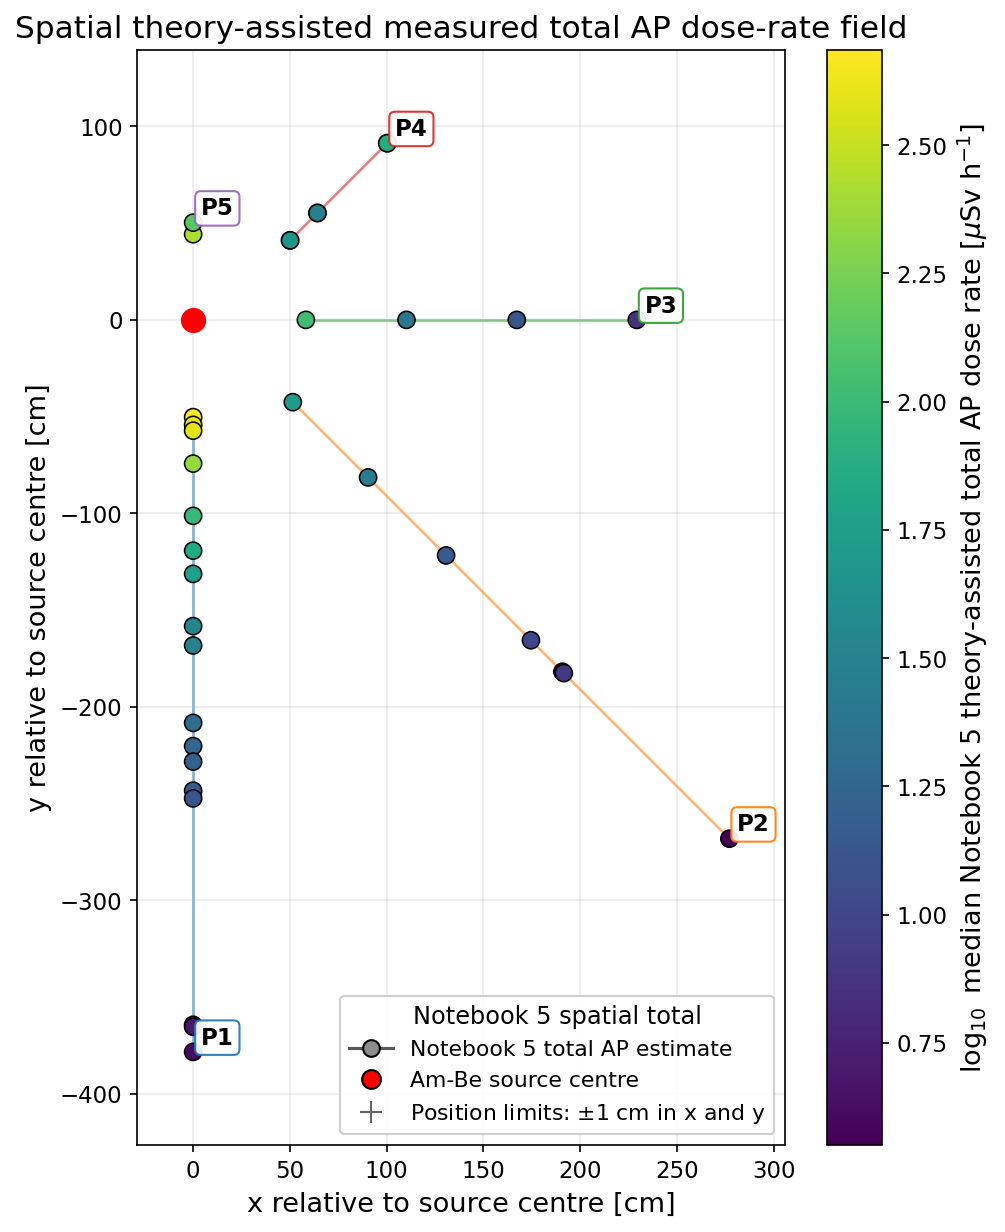

In [7]:
# ============================================================
# 6.1) Spatial Notebook 5 theory-assisted total AP dose field
# ============================================================

required_spatial_total_columns = [
    "position",
    "distance_cm",
    "height_cm",
    "common_dose_x_cm",
    "common_dose_y_cm",
    "measured_total_ap_estimate_uSv_h",
    "u_measured_total_ap_estimate_uSv_h",
    "total_estimate_available",
]

missing_spatial_total_columns = [
    column
    for column in required_spatial_total_columns
    if column not in measured_total_grid_df.columns
]

if missing_spatial_total_columns:
    raise KeyError(
        "The spatial total-dose plot is missing columns: "
        f"{missing_spatial_total_columns}"
    )

valid_spatial_total_df = measured_total_grid_df.loc[
    measured_total_grid_df["total_estimate_available"].fillna(False)
    & np.isfinite(
        measured_total_grid_df[
            "measured_total_ap_estimate_uSv_h"
        ]
    )
    & (
        measured_total_grid_df[
            "measured_total_ap_estimate_uSv_h"
        ] > 0.0
    )
].copy()

if valid_spatial_total_df.empty:
    raise ValueError(
        "No positive Notebook 5 total AP estimates are available "
        "for the spatial plot."
    )

# Collapse coincident XY positions from different target heights.
spatial_total_df = (
    valid_spatial_total_df
    .groupby(
        [
            "position",
            "distance_cm",
            "common_dose_x_cm",
            "common_dose_y_cm",
        ],
        as_index=False,
    )
    .agg(
        median_total_ap_estimate_uSv_h=(
            "measured_total_ap_estimate_uSv_h",
            "median",
        ),
        median_total_standard_uncertainty_uSv_h=(
            "u_measured_total_ap_estimate_uSv_h",
            "median",
        ),
        number_of_available_target_heights=(
            "height_cm",
            "nunique",
        ),
        minimum_target_height_cm=(
            "height_cm",
            "min",
        ),
        maximum_target_height_cm=(
            "height_cm",
            "max",
        ),
    )
)

spatial_total_df[
    "log10_median_total_ap_estimate"
] = np.log10(
    spatial_total_df[
        "median_total_ap_estimate_uSv_h"
    ]
)

spatial_total_figure, spatial_total_axis = plt.subplots(
    figsize=(9.8, 8.1),
    dpi=150,
    layout="constrained",
)

# Position-specific scan lines.
for position in POSITION_SEQUENCE:
    position_curve = (
        spatial_total_df.loc[
            spatial_total_df["position"].eq(position)
        ]
        .sort_values("distance_cm")
    )

    if position_curve.empty:
        continue

    spatial_total_axis.plot(
        position_curve["common_dose_x_cm"],
        position_curve["common_dose_y_cm"],
        color=POSITION_COLORS[position],
        linewidth=1.25,
        alpha=0.58,
        zorder=1,
    )

# Horizontal XY-position limits.
spatial_total_axis.errorbar(
    spatial_total_df["common_dose_x_cm"],
    spatial_total_df["common_dose_y_cm"],
    xerr=DEFAULT_POSITION_LIMIT_CM,
    yerr=DEFAULT_POSITION_LIMIT_CM,
    fmt="none",
    ecolor="0.42",
    elinewidth=0.8,
    capsize=2.5,
    alpha=0.52,
    zorder=2,
)

# Colour represents Notebook 5's final total AP estimate.
spatial_total_scatter = spatial_total_axis.scatter(
    spatial_total_df["common_dose_x_cm"],
    spatial_total_df["common_dose_y_cm"],
    c=spatial_total_df[
        "log10_median_total_ap_estimate"
    ],
    cmap="viridis",
    s=68,
    marker="o",
    edgecolor="black",
    linewidth=0.75,
    zorder=4,
)

# Am-Be source centre.
spatial_total_axis.scatter(
    [0.0],
    [0.0],
    s=125,
    marker="o",
    color="red",
    edgecolor="red",
    linewidth=0.9,
    zorder=6,
)

# P1–P5 endpoint labels.
for position in POSITION_SEQUENCE:
    position_curve = spatial_total_df.loc[
        spatial_total_df["position"].eq(position)
    ]

    if position_curve.empty:
        continue

    label_row = position_curve.loc[
        position_curve["distance_cm"].idxmax()
    ]

    spatial_total_axis.text(
        label_row["common_dose_x_cm"] + 4.0,
        label_row["common_dose_y_cm"] + 4.0,
        position,
        fontsize=11,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": POSITION_COLORS[position],
            "alpha": 0.92,
        },
        zorder=7,
    )

spatial_total_colourbar = spatial_total_figure.colorbar(
    spatial_total_scatter,
    ax=spatial_total_axis,
    pad=0.025,
    fraction=0.052,
)

spatial_total_colourbar.set_label(
    r"$\log_{10}$ median Notebook 5 theory-assisted "
    r"total AP dose rate [$\mu$Sv h$^{-1}$]",
    fontsize=FIGURE_LABEL_FONTSIZE,
)
spatial_total_colourbar.ax.tick_params(
    labelsize=FIGURE_TICK_FONTSIZE,
)

spatial_total_axis.set_xlabel(
    "x relative to source centre [cm]"
)
spatial_total_axis.set_ylabel(
    "y relative to source centre [cm]"
)
spatial_total_axis.set_title(
    "Spatial theory-assisted measured total AP dose-rate field"
)

spatial_total_axis.tick_params(
    axis="both",
    labelsize=FIGURE_TICK_FONTSIZE,
)
spatial_total_axis.set_aspect(
    "equal",
    adjustable="box",
)
spatial_total_axis.grid(
    True,
    alpha=0.25,
)
spatial_total_axis.margins(0.10)

spatial_total_axis.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="-",
            color="0.35",
            markerfacecolor="0.55",
            markeredgecolor="black",
            markersize=8,
            label="Notebook 5 total AP estimate",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            color="red",
            markeredgecolor="black",
            markersize=9,
            label="Am-Be source centre",
        ),
        Line2D(
            [0],
            [0],
            marker="+",
            linestyle="none",
            color="0.4",
            markersize=11,
            label=r"Position limits: $\pm1$ cm in x and y",
        ),
    ],
    title="Notebook 5 spatial total",
    loc="lower right",
    fontsize=FIGURE_LEGEND_FONTSIZE,
    title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
    framealpha=0.94,
    facecolor="white",
)


plt.show()

# 7) Component plot by P-position

The component figure follows Notebook 3's structure. Within each P-panel,
colour shade identifies the exact target height and line style identifies the
component:

- neutron: solid;
- gamma: dashed;
- total: hot pink dash-dot.

Only consecutive target points with a valid component estimate are connected.
This prevents lines from bridging unavailable regions or mixing different
heights.


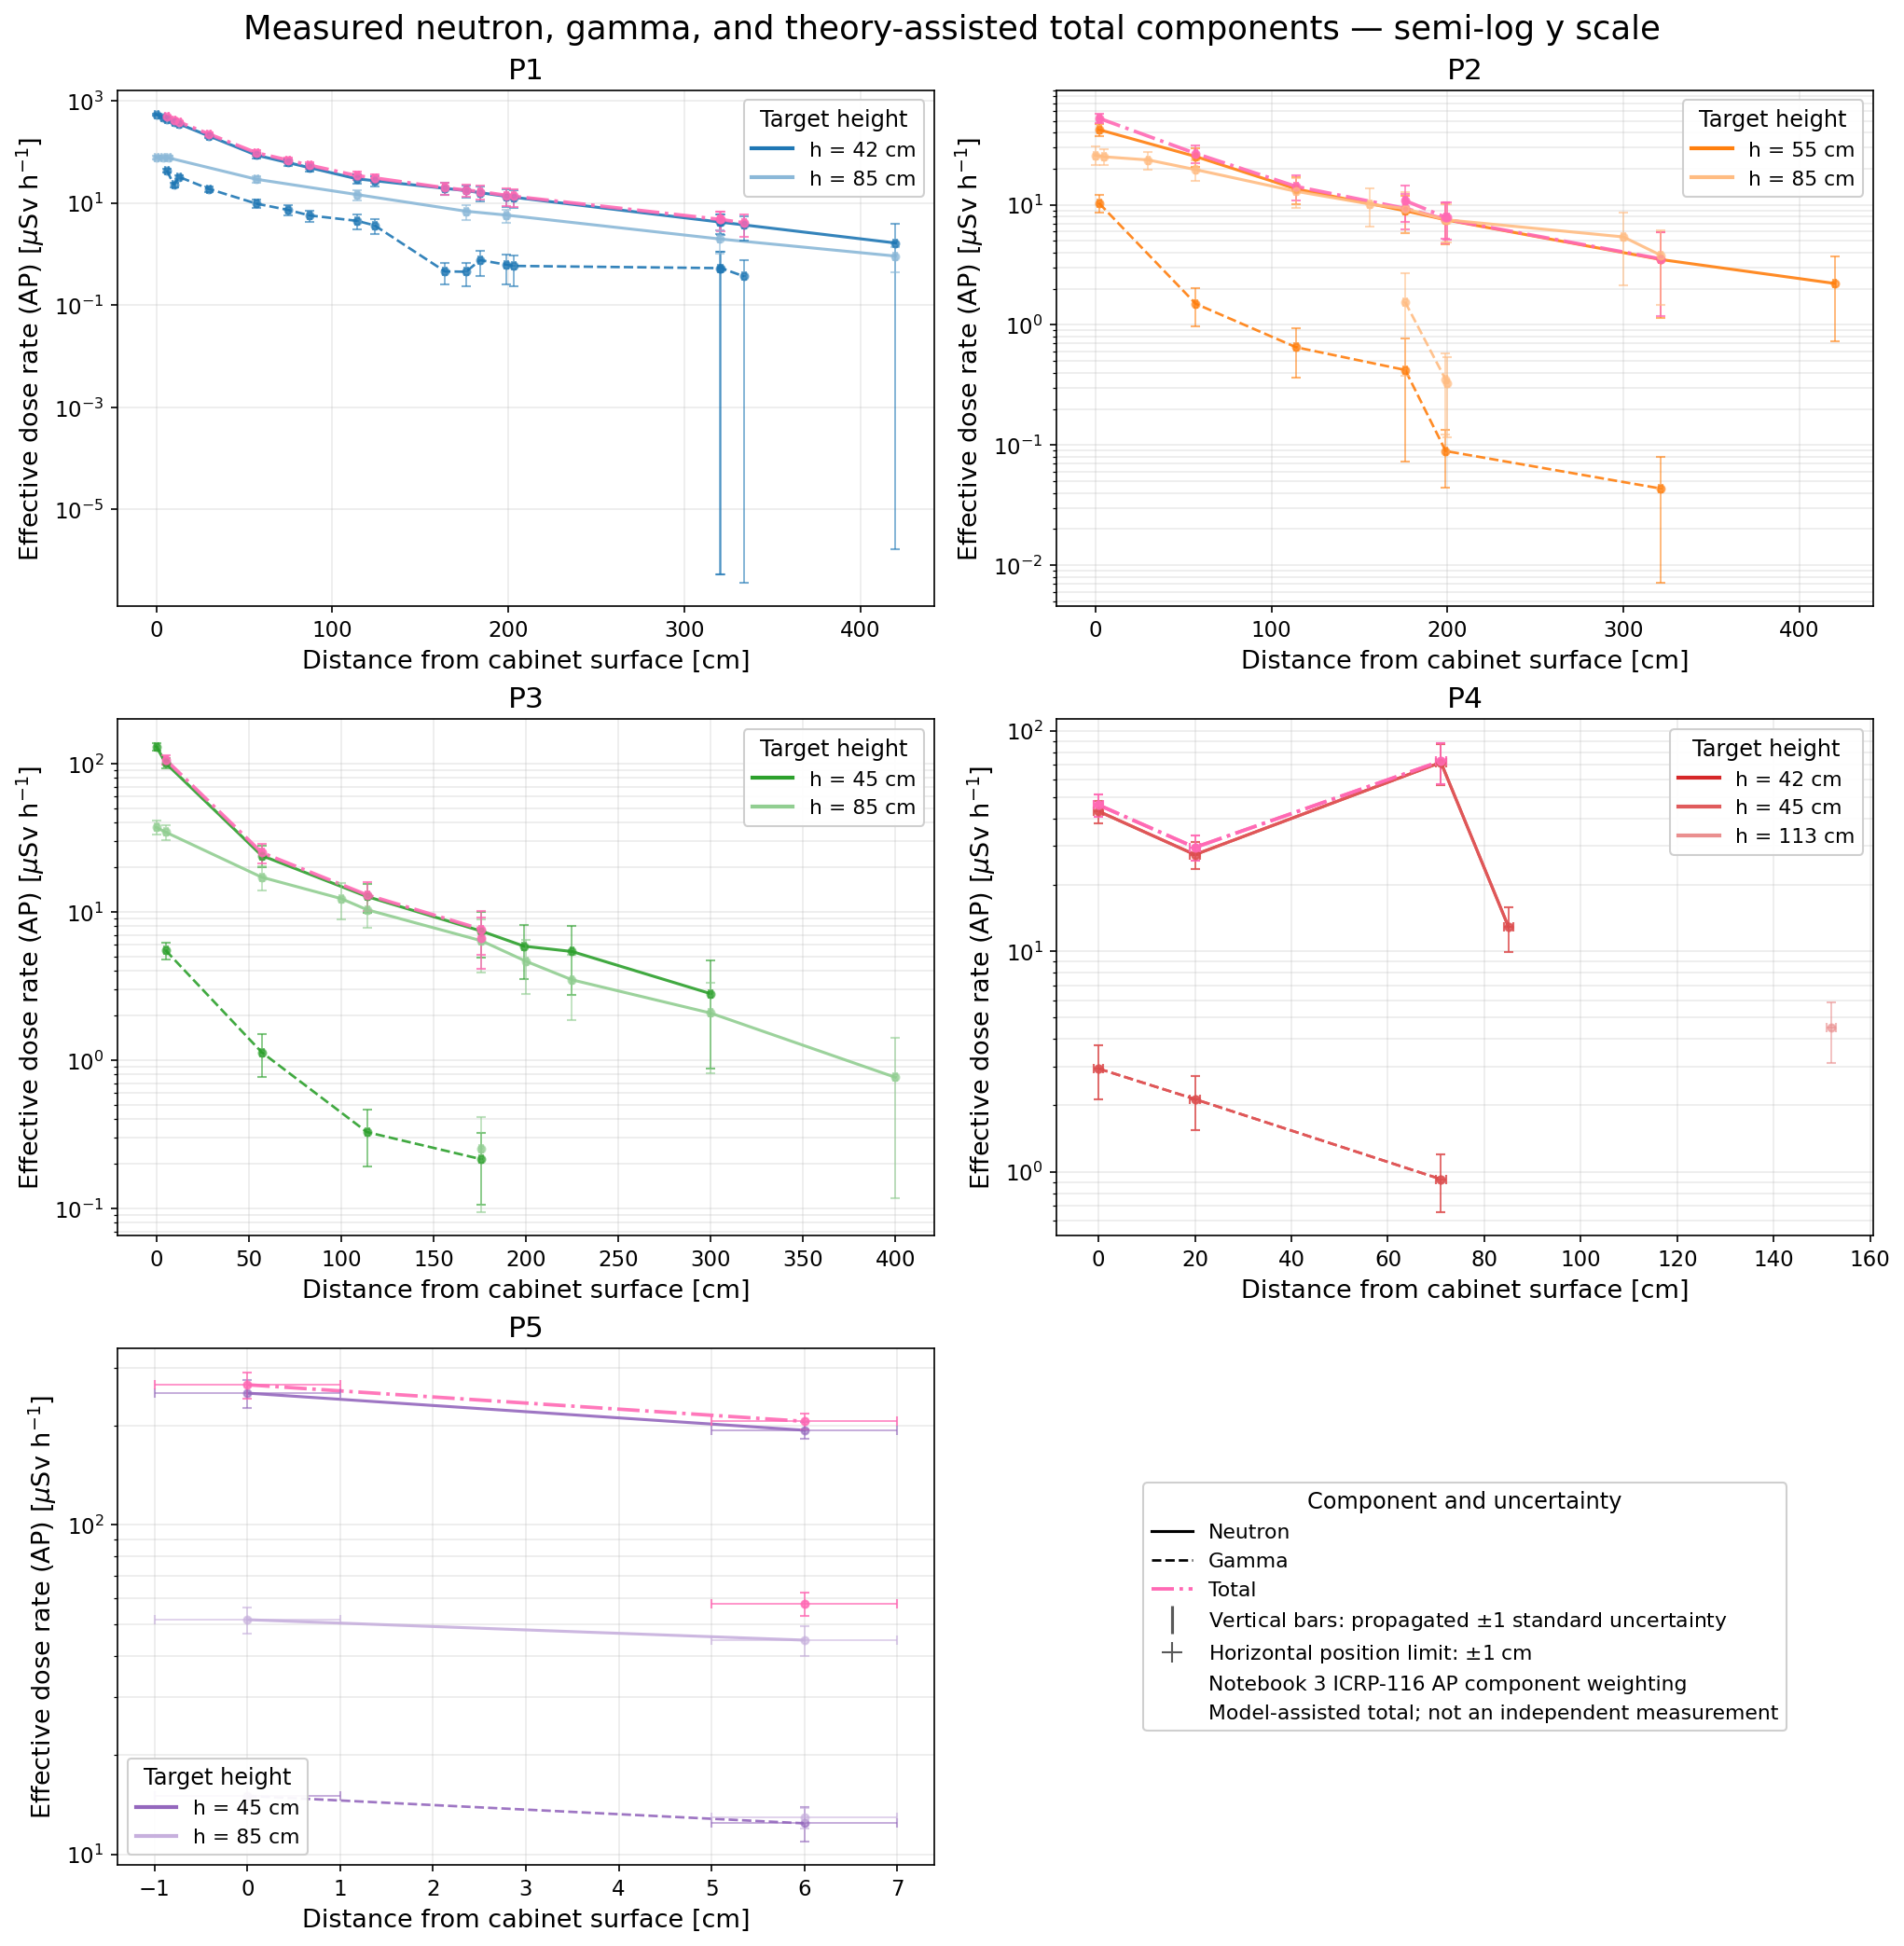

In [8]:
# ============================================================
# 7) Neutron, gamma, and total components by P-position
# ============================================================

def make_position_height_colors(dataframe):
    color_map = {}
    for position in POSITION_SEQUENCE:
        heights = np.sort(
            dataframe.loc[dataframe["position"].eq(position), "height_cm"]
            .dropna().unique()
        )
        if len(heights) == 0:
            continue
        amounts = np.array([0.0]) if len(heights) == 1 else np.linspace(0.0, 0.48, len(heights))
        for height_cm, amount in zip(heights, amounts):
            color_map[(position, float(height_cm))] = lighten_color(
                POSITION_COLORS[position], amount
            )
    return color_map


position_height_colors = make_position_height_colors(measured_total_grid_df)


def plot_connected_valid_segments(axis, dataframe, x_column, y_column, **plot_kwargs):
    sorted_data = dataframe.sort_values(x_column)
    x = sorted_data[x_column].to_numpy(float)
    y = sorted_data[y_column].to_numpy(float)
    valid = np.isfinite(x) & np.isfinite(y) & (y > 0.0)
    segment_start = None
    for index, is_valid in enumerate(valid):
        if is_valid and segment_start is None:
            segment_start = index
        at_end = index == len(valid) - 1
        if segment_start is not None and ((not is_valid) or at_end):
            segment_end = index + 1 if is_valid and at_end else index
            if segment_end - segment_start >= 1:
                axis.plot(
                    x[segment_start:segment_end],
                    y[segment_start:segment_end],
                    **plot_kwargs,
                )
            segment_start = None


component_settings = [
    {
        "label": "Neutron",
        "value_col": "measured_neutron_ap_component_uSv_h",
        "u_col": "u_measured_neutron_ap_component_uSv_h",
        "linestyle": "-",
        "linewidth": 1.5,
        "color_mode": "height",
    },
    {
        "label": "Gamma",
        "value_col": "measured_gamma_ap_component_uSv_h",
        "u_col": "u_measured_gamma_ap_component_uSv_h",
        "linestyle": "--",
        "linewidth": 1.3,
        "color_mode": "height",
    },
    {
        "label": "Total",
        "value_col": "measured_total_ap_estimate_uSv_h",
        "u_col": "u_measured_total_ap_estimate_uSv_h",
        "linestyle": "-.",
        "linewidth": 1.8,
        "color_mode": "total",
    },
]

component_handles = [
    Line2D(
        [0], [0],
        color=TOTAL_COLOR if component["color_mode"] == "total" else "black",
        linestyle=component["linestyle"],
        linewidth=component["linewidth"],
        label=component["label"],
    )
    for component in component_settings
]
uncertainty_handle = Line2D(
    [0], [0],
    color="0.35",
    marker="|",
    markeredgewidth=1.5,
    markersize=14,
    linestyle="none",
    label=r"Vertical bars: propagated $\pm1$ standard uncertainty",
)

component_figure, component_axes = plt.subplots(
    3, 2, figsize=(13.5, 13.8), dpi=150, layout="constrained"
)
component_axes = component_axes.flatten()

for axis_index, position in enumerate(POSITION_SEQUENCE):
    axis = component_axes[axis_index]
    position_data = measured_total_grid_df.loc[
        measured_total_grid_df["position"].eq(position)
    ]
    height_handles = []

    for height_cm, curve_data in position_data.groupby("height_cm", sort=True):
        curve_data = curve_data.sort_values("distance_cm")
        height_color = position_height_colors[(position, float(height_cm))]
        for component in component_settings:
            color = TOTAL_COLOR if component["color_mode"] == "total" else height_color
            plot_connected_valid_segments(
                axis,
                curve_data,
                "distance_cm",
                component["value_col"],
                color=color,
                linestyle=component["linestyle"],
                linewidth=component["linewidth"],
                alpha=0.90,
                zorder=2,
            )
            valid = (
                np.isfinite(curve_data[component["value_col"]])
                & (curve_data[component["value_col"]] > 0.0)
                & np.isfinite(curve_data[component["u_col"]])
                & (curve_data[component["u_col"]] >= 0.0)
            )
            if valid.any():
                axis.errorbar(
                    curve_data.loc[valid, "distance_cm"],
                    curve_data.loc[valid, component["value_col"]],
                    xerr=curve_data.loc[valid, "horizontal_position_limit_cm"],
                    yerr=log_safe_yerr(
                        curve_data.loc[valid, component["value_col"]],
                        curve_data.loc[valid, component["u_col"]],
                    ),
                    fmt="o",
                    linestyle="none",
                    markersize=3.8,
                    markerfacecolor=color,
                    markeredgecolor=color,
                    ecolor=color,
                    elinewidth=0.85,
                    capsize=2.5,
                    alpha=0.60 if component["label"] != "Total" else 0.78,
                    zorder=3,
                )

        height_handles.append(
            Line2D(
                [0], [0], color=height_color, linestyle="-", linewidth=2.0,
                label=f"h = {height_cm:g} cm",
            )
        )

    height_legend = axis.legend(
        handles=height_handles,
        title="Target height",
        loc="lower left" if position == "P5" else "upper right",
        fontsize=FIGURE_LEGEND_FONTSIZE,
        title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
        framealpha=0.94,
        facecolor="white",
    )

    axis.set_yscale("log")
    axis.set_title(position)
    axis.set_xlabel("Distance from cabinet surface [cm]")
    axis.set_ylabel(r"Effective dose rate (AP) [$\mu$Sv h$^{-1}$]")
    axis.grid(True, which="both", alpha=0.25)
    axis.set_axisbelow(True)

component_axes[-1].axis("off")
component_axes[-1].legend(
    handles=component_handles + [
        uncertainty_handle,
        Line2D([0], [0], marker="+", linestyle="none", color="0.35",
               markersize=11, label=r"Horizontal position limit: $\pm1$ cm"),
        Line2D([0], [0], color="none", linestyle="none",
               label="Notebook 3 ICRP-116 AP component weighting"),
        Line2D([0], [0], color="none", linestyle="none",
               label="Model-assisted total; not an independent measurement"),
    ],
    title="Component and uncertainty",
    loc="center",
    fontsize=FIGURE_LEGEND_FONTSIZE,
    title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
    framealpha=0.94,
    facecolor="white",
)

component_figure.suptitle(
    "Measured neutron, gamma, and theory-assisted total components — semi-log y scale",
    fontsize=FIGURE_SUPTITLE_FONTSIZE,
)

plt.show()


# 8) Total-field overview figures

Three report-oriented total figures are produced:

1. all available exact target heights together;
2. lower-height targets only;
3. upper-height targets only.

Colour and shade identify P-position and exact target height exactly as in
Notebook 3. Gaps remain gaps: invalid or unsupported points are not bridged.


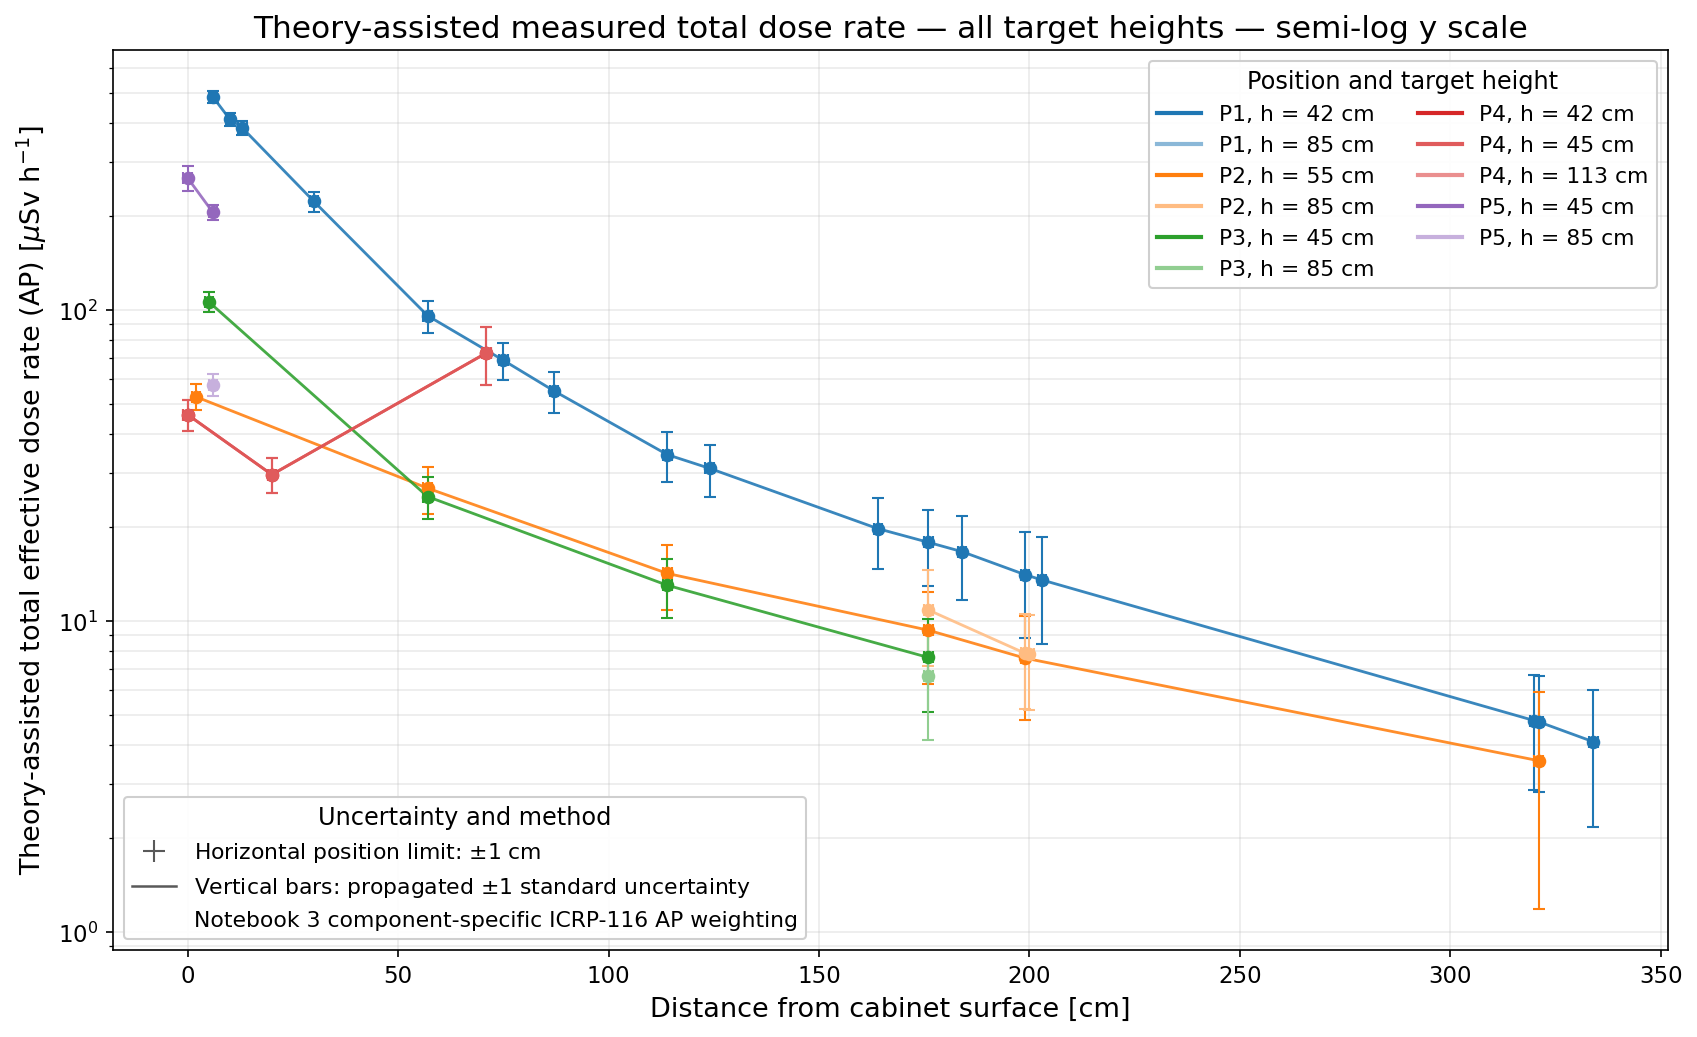

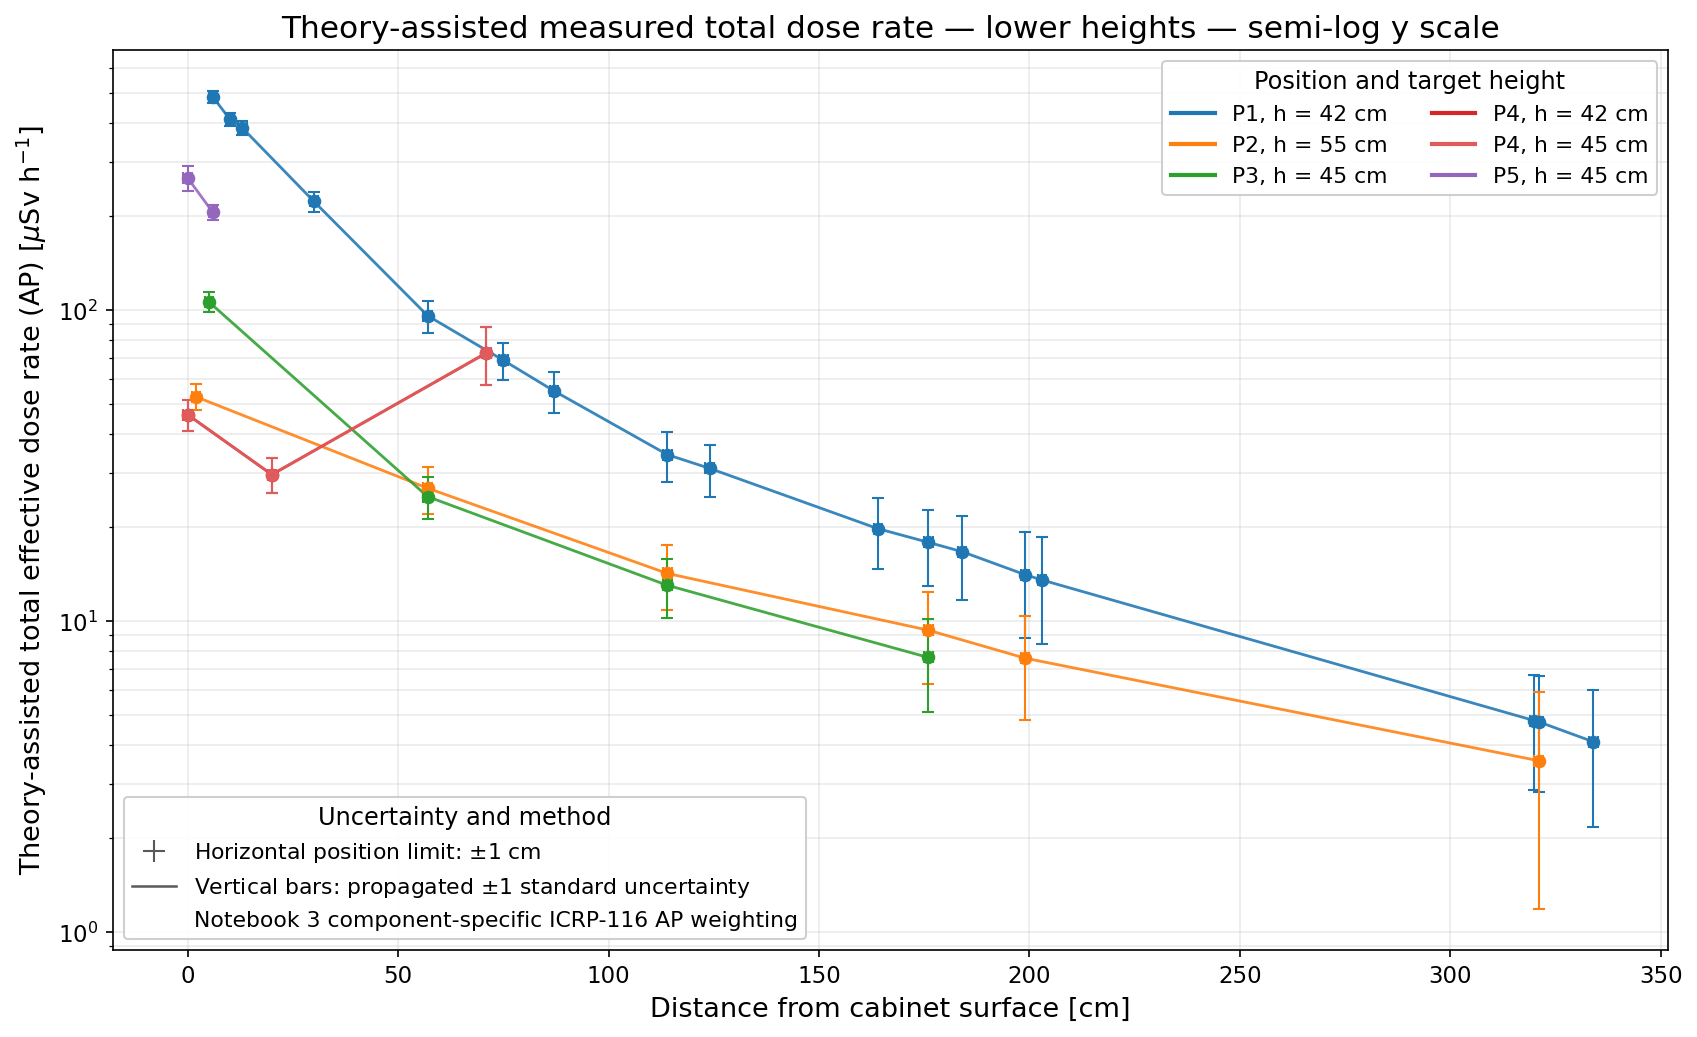

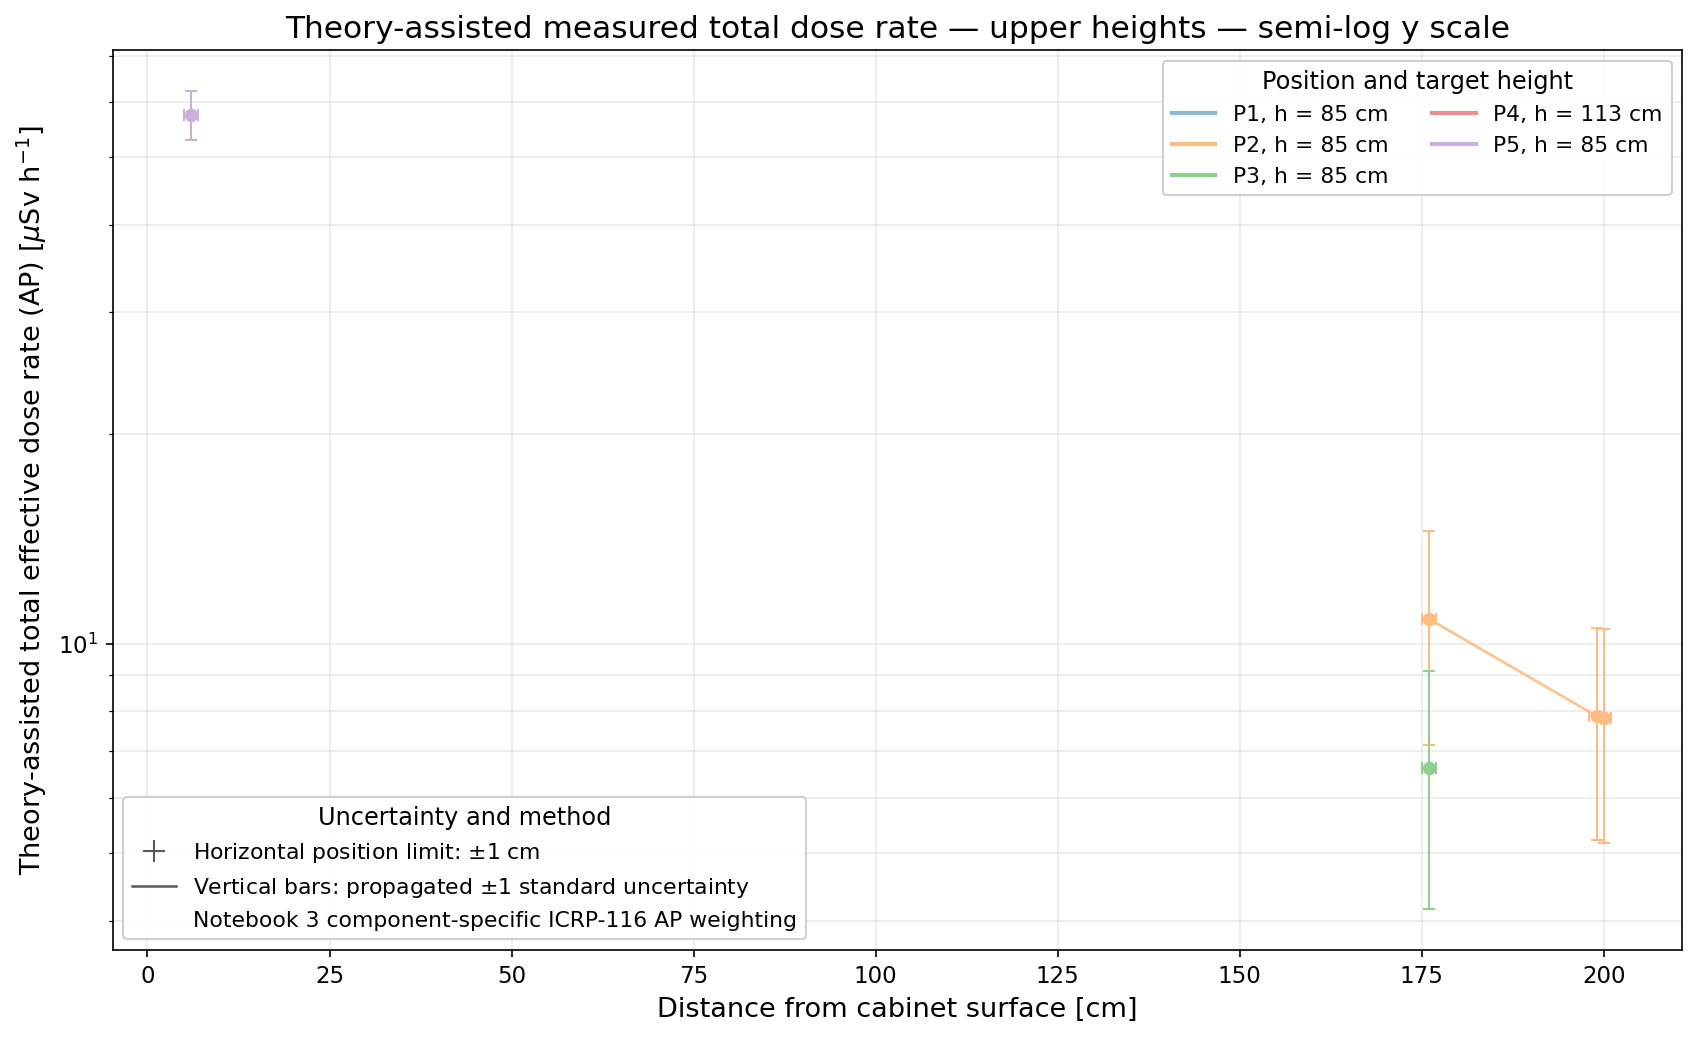

In [9]:
# ============================================================
# 8) Total all-height, lower-height, and upper-height figures
# ============================================================

def plot_total_overview(dataframe, title, method_legend_loc="lower left"):
    figure, axis = plt.subplots(
        figsize=(11.2, 6.8), dpi=150, layout="constrained"
    )
    curve_handles = []
    for (position, height_cm), curve in dataframe.groupby(
        ["position", "height_cm"], sort=True
    ):
        curve = curve.sort_values("distance_cm")
        color = position_height_colors[(position, float(height_cm))]
        plot_connected_valid_segments(
            axis,
            curve,
            "distance_cm",
            "measured_total_ap_estimate_uSv_h",
            color=color,
            linestyle="-",
            linewidth=1.35,
            alpha=0.88,
            zorder=2,
        )
        valid = (
            curve["total_estimate_available"]
            & np.isfinite(curve["measured_total_ap_estimate_uSv_h"])
            & (curve["measured_total_ap_estimate_uSv_h"] > 0.0)
            & np.isfinite(curve["u_measured_total_ap_estimate_uSv_h"])
        )
        if valid.any():
            axis.errorbar(
                curve.loc[valid, "distance_cm"],
                curve.loc[valid, "measured_total_ap_estimate_uSv_h"],
                xerr=curve.loc[valid, "horizontal_position_limit_cm"],
                yerr=log_safe_yerr(
                    curve.loc[valid, "measured_total_ap_estimate_uSv_h"],
                    curve.loc[valid, "u_measured_total_ap_estimate_uSv_h"],
                ),
                fmt="o",
                linestyle="none",
                color=color,
                markerfacecolor=color,
                markeredgecolor=color,
                markersize=5.5,
                ecolor=color,
                elinewidth=1.0,
                capsize=3,
                zorder=3,
            )
        curve_handles.append(
            Line2D(
                [0], [0], color=color, linewidth=2.0,
                label=f"{position}, h = {height_cm:g} cm",
            )
        )

    axis.set_yscale("log")
    axis.set_xlabel("Distance from cabinet surface [cm]")
    axis.set_ylabel(r"Theory-assisted total effective dose rate (AP) [$\mu$Sv h$^{-1}$]")
    axis.set_title(title)
    axis.grid(True, which="both", alpha=0.25)
    axis.set_axisbelow(True)

    curve_legend = axis.legend(
        handles=curve_handles,
        title="Position and target height",
        loc="upper right",
        ncol=2,
        fontsize=FIGURE_LEGEND_FONTSIZE,
        title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
        framealpha=0.94,
        facecolor="white",
    )
    axis.add_artist(curve_legend)
    axis.legend(
        handles=[
            Line2D([0], [0], marker="+", linestyle="none", color="0.35",
                   markersize=11, label=r"Horizontal position limit: $\pm1$ cm"),
            Line2D([0], [0], color="0.35", linewidth=1.2,
                   label=r"Vertical bars: propagated $\pm1$ standard uncertainty"),
            Line2D([0], [0], color="none", linestyle="none",
                   label="Notebook 3 component-specific ICRP-116 AP weighting"),
        ],
        title="Uncertainty and method",
        loc=method_legend_loc,
        fontsize=FIGURE_LEGEND_FONTSIZE,
        title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
        framealpha=0.94,
        facecolor="white",
    )
    return figure


total_all_heights_figure = plot_total_overview(
    measured_total_grid_df,
    "Theory-assisted measured total dose rate — all target heights — semi-log y scale",
)
total_lower_height_figure = plot_total_overview(
    measured_total_grid_df.loc[
        measured_total_grid_df["analysis_height_interval"].eq("lower")
    ],
    "Theory-assisted measured total dose rate — lower heights — semi-log y scale",
)
total_upper_height_figure = plot_total_overview(
    measured_total_grid_df.loc[
        measured_total_grid_df["analysis_height_interval"].eq("upper")
    ],
    "Theory-assisted measured total dose rate — upper heights — semi-log y scale",
    method_legend_loc="lower left",
)

plt.show()


# 9) Position-wise total field

The P1--P5 panel figure gives the same total result with one subplot per scan
direction. Exact target heights remain separate and use the same shades as the
component and overview figures. P5's height legend is placed in the lower-left
corner; the common uncertainty explanation occupies the unused sixth panel.


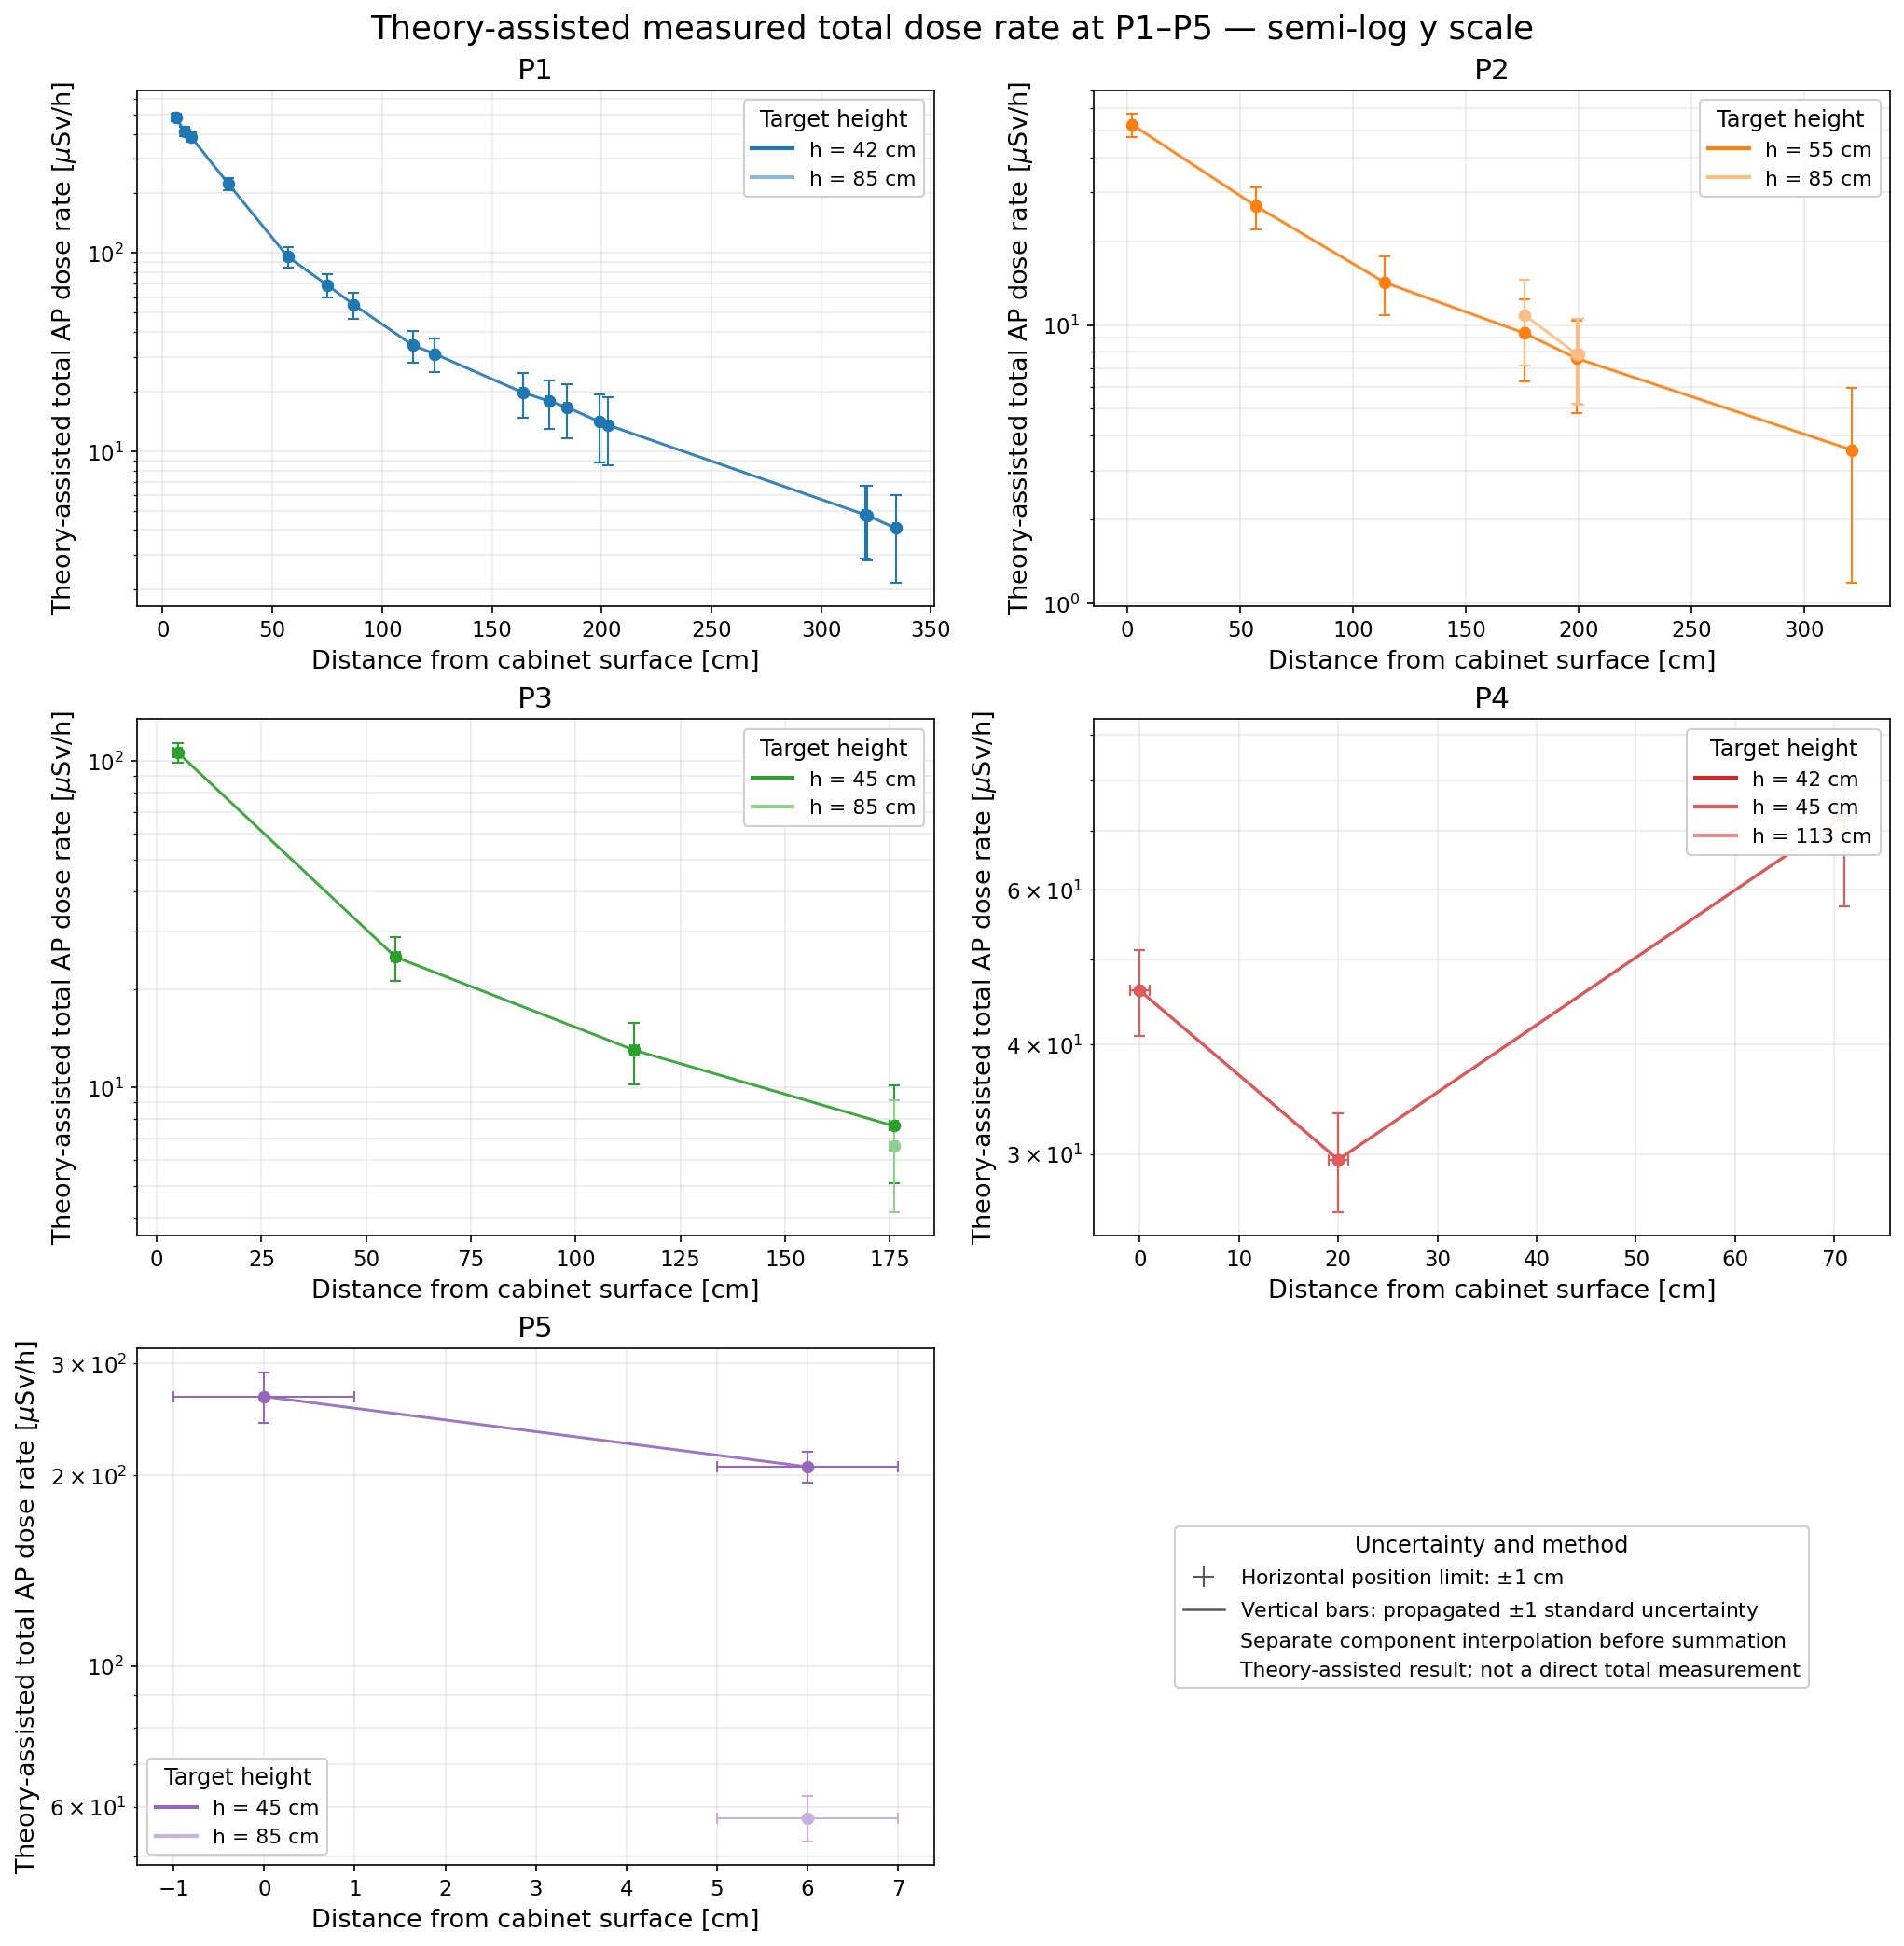

In [10]:
# ============================================================
# 9) Total field at P1–P5 — one subplot per position
# ============================================================

total_position_figure, total_position_axes = plt.subplots(
    3, 2, figsize=(13.5, 13.8), dpi=150, layout="constrained"
)
total_position_axes = total_position_axes.flatten()

for axis_index, position in enumerate(POSITION_SEQUENCE):
    axis = total_position_axes[axis_index]
    position_data = measured_total_grid_df.loc[
        measured_total_grid_df["position"].eq(position)
    ]
    handles = []
    for height_cm, curve in position_data.groupby("height_cm", sort=True):
        curve = curve.sort_values("distance_cm")
        color = position_height_colors[(position, float(height_cm))]
        plot_connected_valid_segments(
            axis,
            curve,
            "distance_cm",
            "measured_total_ap_estimate_uSv_h",
            color=color,
            linestyle="-",
            linewidth=1.45,
            alpha=0.90,
            zorder=2,
        )
        valid = (
            curve["total_estimate_available"]
            & (curve["measured_total_ap_estimate_uSv_h"] > 0.0)
            & np.isfinite(curve["u_measured_total_ap_estimate_uSv_h"])
        )
        if valid.any():
            axis.errorbar(
                curve.loc[valid, "distance_cm"],
                curve.loc[valid, "measured_total_ap_estimate_uSv_h"],
                xerr=curve.loc[valid, "horizontal_position_limit_cm"],
                yerr=log_safe_yerr(
                    curve.loc[valid, "measured_total_ap_estimate_uSv_h"],
                    curve.loc[valid, "u_measured_total_ap_estimate_uSv_h"],
                ),
                fmt="o", linestyle="none", color=color,
                markersize=5.5, capsize=3, elinewidth=1.0, zorder=3,
            )
        handles.append(
            Line2D(
                [0], [0], color=color, linewidth=2.0,
                label=f"h = {height_cm:g} cm",
            )
        )

    axis.set_yscale("log")
    axis.set_title(position)
    axis.set_xlabel("Distance from cabinet surface [cm]")
    axis.set_ylabel(r"Theory-assisted total AP dose rate [$\mu$Sv/h]")
    axis.grid(True, which="both", alpha=0.25)
    axis.set_axisbelow(True)
    axis.legend(
        handles=handles,
        title="Target height",
        loc="lower left" if position == "P5" else "upper right",
        fontsize=FIGURE_LEGEND_FONTSIZE,
        title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
        framealpha=0.94,
        facecolor="white",
    )

total_position_axes[-1].axis("off")
total_position_axes[-1].legend(
    handles=[
        Line2D([0], [0], marker="+", linestyle="none", color="0.35",
               markersize=11, label=r"Horizontal position limit: $\pm1$ cm"),
        Line2D([0], [0], color="0.35", linewidth=1.2,
               label=r"Vertical bars: propagated $\pm1$ standard uncertainty"),
        Line2D([0], [0], color="none", linestyle="none",
               label="Separate component interpolation before summation"),
        Line2D([0], [0], color="none", linestyle="none",
               label="Theory-assisted result; not a direct total measurement"),
    ],
    title="Uncertainty and method",
    loc="center",
    fontsize=FIGURE_LEGEND_FONTSIZE,
    title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
    framealpha=0.94,
    facecolor="white",
)
total_position_figure.suptitle(
    "Theory-assisted measured total dose rate at P1–P5 — semi-log y scale",
    fontsize=FIGURE_SUPTITLE_FONTSIZE,
)

plt.show()


# 10) Export the final Notebook 5 handoff

The canonical Notebook 6 handoff is the target-grid table containing the
separate neutron component, separate gamma component, their propagated
uncertainties, and their sum. The scaled measured-point table and theoretical
factor table are exported as audits.

The result may be compared with Notebook 3 as a model-assisted consistency
check, but not as an independent validation, because Notebook 3 supplies the
component-specific spectral conversion factors. Independent validation still
requires the separate measured-neutron and measured-gamma comparisons.


In [12]:
display(total_grid_summary_df)
display(measured_total_grid_df.head(12))

,position,analysis_height_interval,target_points,neutron_component_points,gamma_component_points,total_points,minimum_total_uSv_h,maximum_total_uSv_h
0,P1,lower,20,20,17,17,4.088485,484.647184
1,P1,upper,9,9,0,0,NaN,NaN
2,P2,lower,7,7,6,6,3.553500,52.593862
3,P2,upper,12,11,3,3,7.823956,10.848075
4,P3,lower,9,8,4,4,7.631487,106.351340
5,P3,upper,10,10,1,1,6.636903,6.636903
6,P4,lower,8,8,6,6,29.567544,72.821080
7,P4,upper,2,1,0,0,NaN,NaN
8,P5,lower,2,2,2,2,205.984765,265.912836
9,P5,upper,2,2,1,1,57.579360,57.579360


,point_name,position,distance_cm,height_cm,common_dose_x_cm,common_dose_y_cm,common_dose_z_cm,gamma_flux_x_cm,gamma_flux_y_cm,gamma_flux_z_cm,analysis_height_interval,analysis_height_interval_label,target_grid_origin,geometry_reconstruction_mode,measured_neutron_ap_component_uSv_h,u_measured_neutron_ap_component_uSv_h,measured_gamma_ap_component_uSv_h,u_measured_gamma_ap_component_uSv_h,measured_total_ap_estimate_uSv_h,u_measured_total_ap_estimate_uSv_h,neutron_component_available,gamma_component_available,total_estimate_available,neutron_height_interpolation_mode,gamma_height_interpolation_mode,neutron_support_minimum_height_cm,neutron_support_maximum_height_cm,gamma_support_minimum_height_cm,gamma_support_maximum_height_cm,horizontal_position_limit_cm,vertical_uncertainty_scope,result_status,relative_total_uncertainty_percent
0,P1_x0_h42,P1,0.0,42.0,0.0,-44.25,1.0,0.0,-35.405,1.0,lower,Lower height interval (38–65 cm),Notebook 3 target point,original Notebook 3 geometry,541.600000,25.412725,NaN,NaN,NaN,NaN,True,False,False,single measured height represents interval,unavailable,42.0,42.0,NaN,NaN,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independent,theory-assisted AP component sum; not an independent direct total measurement,NaN
1,P1_x4_h42,P1,4.0,42.0,0.0,-48.25,1.0,0.0,-39.405,1.0,lower,Lower height interval (38–65 cm),Notebook 3 target point,original Notebook 3 geometry,470.483333,22.373505,NaN,NaN,NaN,NaN,True,False,False,single measured height represents interval,unavailable,42.0,42.0,NaN,NaN,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independent,theory-assisted AP component sum; not an independent direct total measurement,NaN
2,N5_P1_x6_h42,P1,6.0,42.0,0.0,-50.25,1.0,0.0,-41.405,1.0,lower,Lower height interval (38–65 cm),measured distance added to Notebook 3 target height,position-specific least-squares Notebook 3 coordinate plane,441.303999,21.795868,43.343185,3.818087,484.647184,22.127757,True,True,True,single measured height represents interval,single measured height represents interval,42.0,42.0,50.0,50.0,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independent,theory-assisted AP component sum; not an independent direct total measurement,4.565746
3,N5_P1_x10_h42,P1,10.0,42.0,0.0,-54.25,1.0,0.0,-45.405,1.0,lower,Lower height interval (38–65 cm),measured distance added to Notebook 3 target height,position-specific least-squares Notebook 3 coordinate plane,388.262193,20.684949,22.707816,2.126203,410.970009,20.793938,True,True,True,single measured height represents interval,single measured height represents interval,42.0,42.0,50.0,50.0,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independent,theory-assisted AP component sum; not an independent direct total measurement,5.059721
4,N5_P1_x13_h42,P1,13.0,42.0,0.0,-57.25,1.0,0.0,-48.405,1.0,lower,Lower height interval (38–65 cm),measured distance added to Notebook 3 target height,position-specific least-squares Notebook 3 coordinate plane,352.708181,19.889079,32.371576,3.159693,385.079757,20.138498,True,True,True,single measured height represents interval,single measured height represents interval,42.0,42.0,45.0,45.0,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independent,theory-assisted AP component sum; not an independent direct total measurement,5.229695
5,N5_P1_x30_h42,P1,30.0,42.0,0.0,-74.25,1.0,0.0,-65.405,1.0,lower,Lower height interval (38–65 cm),measured distance added to Notebook 3 target height,position-specific least-squares Notebook 3 coordinate plane,204.673353,15.924136,18.827587,2.357735,223.500940,16.097734,True,True,True,single measured height represents interval,interpolated between measured heights,42.0,42.0,38.0,45.0,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independen

In [13]:
# ============================================================
# 10) Save tables, figures, metadata, and Notebook 6 handoff
# ============================================================

tables_to_save = {
    "unified_measured_radiation_field_long.csv": measured_unified_long_df,
    "unified_measured_neutron_component.csv": measured_neutron_component_df,
    "unified_measured_gamma_component.csv": measured_gamma_component_df,
    "scaled_measured_components_component_specific.csv": scaled_measured_components_df,
    "measured_total_ap_field_common_grid_final.csv": measured_total_grid_df,
    "measured_total_ap_field_summary.csv": total_grid_summary_df,
    "measurement_coverage_summary.csv": measurement_coverage_summary_df,
    "notebook_3_component_conversion_factors.csv": theory_conversion_df,
    "notebook_3_component_conversion_factor_summary.csv": conversion_factor_summary_df,
    "notebook_3_original_target_grid.csv": notebook3_target_grid_df,
    "notebook_5_common_target_grid.csv": target_grid_df,
    "notebook_3_target_grid_summary.csv": target_grid_summary_df,
    "spatial_neutron_response_references.csv": spatial_neutron_df,
    "spatial_gamma_response_references.csv": spatial_gamma_df,
    "notebook_1_6_broad_energy_group_crosscheck.csv": n1_6_energy_group_audit_df,
    "input_audit.csv": input_audit_df,
}

saved_table_rows = []
for filename, dataframe in tables_to_save.items():
    path = TABLE_DIR / filename
    dataframe.to_csv(path, index=False)
    saved_table_rows.append({
        "filename": filename,
        "path": str(path.resolve()),
        "rows": len(dataframe),
    })
saved_tables_df = pd.DataFrame(saved_table_rows)

figures_to_save = {
    "measured_field_response_reference_geometry": spatial_geometry_figure,
    "measured_total_ap_spatial_field": spatial_total_figure,
    "measured_components_by_position": component_figure,
    "measured_total_all_target_heights": total_all_heights_figure,
    "measured_total_lower_height": total_lower_height_figure,
    "measured_total_upper_height": total_upper_height_figure,
    "measured_total_by_position": total_position_figure,
}

saved_figure_rows = []
for stem, figure in figures_to_save.items():
    png_path = FIGURE_DIR / f"{stem}.png"
    pdf_path = FIGURE_DIR / f"{stem}.pdf"
    figure.savefig(png_path, dpi=300, bbox_inches="tight")
    figure.savefig(pdf_path, bbox_inches="tight")
    saved_figure_rows.append({
        "stem": stem,
        "png_path": str(png_path.resolve()),
        "pdf_path": str(pdf_path.resolve()),
    })
saved_figures_df = pd.DataFrame(saved_figure_rows)

metadata_df = pd.DataFrame([
    {
        "quantity": "notebook",
        "value": "Notebook_5.ipynb",
        "unit": "",
        "note": "measured components and theory-assisted total AP field",
    },
    {
        "quantity": "lower_analysis_height_interval",
        "value": "38 to 65 inclusive",
        "unit": "cm",
        "note": "measured interpolation support; exact target heights retained",
    },
    {
        "quantity": "upper_analysis_height_interval",
        "value": "85 to 113 inclusive",
        "unit": "cm",
        "note": "measured interpolation support; exact target heights retained",
    },
    {
        "quantity": "neutron_conversion_factor",
        "value": "Notebook 3 neutron AP component / Studsvik-labelled neutron proxy",
        "unit": "dimensionless",
        "note": "component-specific; never total/proxy",
    },
    {
        "quantity": "gamma_conversion_factor",
        "value": "Notebook 3 gamma AP component / GCA Cs137-equivalent proxy",
        "unit": "dimensionless",
        "note": "component-specific; never total/proxy",
    },
    {
        "quantity": "interpolation_method",
        "value": "log-linear distance interpolation followed by height interpolation",
        "unit": "",
        "note": "performed independently for neutron and gamma within P and interval",
    },
    {
        "quantity": "extrapolation_policy",
        "value": "no measured-field extrapolation",
        "unit": "",
        "note": "targets outside measured component distance support remain unavailable",
    },
    {
        "quantity": "theory_factor_endpoint_policy",
        "value": "nearest factor in the same P-position and height interval",
        "unit": "",
        "note": "used only outside discrete Notebook 3 factor nodes and flagged per measured point",
    },
    {
        "quantity": "single_height_interval_policy",
        "value": "single measured-height curve represents the selected interval",
        "unit": "",
        "note": "mode and support height exported for every target point",
    },
    {
        "quantity": "total_definition",
        "value": "interpolated neutron AP component plus interpolated gamma AP component",
        "unit": "uSv/h",
        "note": "components are never alternated in one connected curve",
    },
    {
        "quantity": "uncertainty_scope",
        "value": "measurement SEM plus Notebook 3 MC factor uncertainty",
        "unit": "",
        "note": "zero covariance for ratio terms; component totals treated independent",
    },
    {
        "quantity": "excluded_systematic_uncertainties",
        "value": "geometry, material composition, nuclear data, source strength, complete detector response",
        "unit": "",
        "note": "documented but not included in plotted standard uncertainty",
    },
    {
        "quantity": "Notebook_1_6_energy_use",
        "value": "qualitative broad leakage-energy cross-check",
        "unit": "particle-rate fraction",
        "note": "not used numerically as dose weights",
    },
    {
        "quantity": "result_independence",
        "value": "not independent of Notebook 3",
        "unit": "",
        "note": "Notebook 3 supplies the component conversion fields",
    },
])
metadata_path = METADATA_DIR / "notebook_5_analysis_metadata.csv"
metadata_df.to_csv(metadata_path, index=False)

handoff_manifest_df = pd.DataFrame([
    {
        "consumer_notebook": "Notebook 6",
        "purpose": "canonical theory-assisted total AP field",
        "canonical_path": str(
            TABLE_DIR / "measured_total_ap_field_common_grid_final.csv"
        ),
        "comparison_rule": (
            "Use as a model-assisted consistency comparison; retain separate "
            "neutron and gamma comparisons as the independent validation."
        ),
    },
    {
        "consumer_notebook": "Notebook 6",
        "purpose": "measured component and factor audit",
        "canonical_path": str(
            TABLE_DIR / "scaled_measured_components_component_specific.csv"
        ),
        "comparison_rule": (
            "Retain radiation type, actual measured height, component factor, "
            "measurement SEM, and Notebook 3 MC factor term."
        ),
    },
])
handoff_manifest_path = METADATA_DIR / "notebook_5_handoff_manifest.csv"
handoff_manifest_df.to_csv(handoff_manifest_path, index=False)

summary_json = {
    "analysis": "component-specific theory-assisted measured total AP field",
    "component_conversion": {
        "neutron": "Notebook 3 neutron AP component / Studsvik-labelled neutron proxy",
        "gamma": "Notebook 3 gamma AP component / GCA Cs137-equivalent proxy",
    },
    "height_intervals_cm": ANALYSIS_HEIGHT_INTERVALS_CM,
    "target_grid_points": int(len(measured_total_grid_df)),
    "total_estimates_available": int(
        measured_total_grid_df["total_estimate_available"].sum()
    ),
    "measured_field_extrapolation_used": False,
    "theory_factor_endpoint_representative_values_allowed": True,
    "result_is_independent_measurement": False,
    "canonical_output": str(
        TABLE_DIR / "measured_total_ap_field_common_grid_final.csv"
    ),
}
summary_json_path = METADATA_DIR / "notebook_5_analysis_summary.json"
summary_json_path.write_text(
    json.dumps(summary_json, indent=2) + "\n", encoding="utf-8"
)

print("Notebook 5 outputs saved.")
print(
    "Canonical Notebook 6 handoff: "
    f"{TABLE_DIR / 'measured_total_ap_field_common_grid_final.csv'}"
)
print(f"Metadata: {metadata_path}")
print(f"Handoff manifest: {handoff_manifest_path}")
display(saved_tables_df)
display(saved_figures_df)


Notebook 5 outputs saved.
Canonical Notebook 6 handoff: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/measured_total_ap_field_common_grid_final.csv
Metadata: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/metadata/notebook_5_analysis_metadata.csv
Handoff manifest: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/metadata/notebook_5_handoff_manifest.csv


,filename,path,rows
0,unified_measured_radiation_field_long.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/unified_measured_radiation_field_long.csv,106
1,unified_measured_neutron_component.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/unified_measured_neutron_component.csv,61
2,unified_measured_gamma_component.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/unified_measured_gamma_component.csv,45
3,scaled_measured_components_component_specific.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/scaled_measured_components_component_specific.csv,106
4,measured_total_ap_field_common_grid_final.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/measured_total_ap_field_common_grid_final.csv,81
5,measured_total_ap_field_summary.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/measured_total_ap_field_summary.csv,10
6,measurement_coverage_summary.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/measurement_coverage_summary.csv,19
7,notebook_3_component_conversion_factors.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/notebook_3_component_conversion_factors.csv,61
8,notebook_3_component_conversion_factor_summary.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/notebook_3_component_conversion_factor_summary.csv,10
9,notebook_3_original_target_grid.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/notebook_3_original_target_grid.csv,61


,stem,png_path,pdf_path
0,measured_field_response_reference_geometry,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/figures/measured_field_response_reference_geometry.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/figures/measured_field_response_reference_geometry.pdf
1,measured_total_ap_spatial_field,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/figures/measured_total_ap_spatial_field.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/figures/measured_total_ap_spatial_field.pdf
2,measured_components_by_position,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/figures/measured_components_by_position.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/figures/measured_components_by_position.pdf
3,measured_total_all_target_heights,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/figures/measured_total_all_target_heights.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/figures/measured_total_all_target_heights.pdf
4,measured_total_lower_height,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/figures/measured_total_lower_height.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/figures/measured_total_lower_height.pdf
5,measured_total_upper_height,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/figures/measured_total_upper_height.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/figures/measured_total_upper_height.pdf
6,measured_total_by_position,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/figures/measured_total_by_position.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/figures/measured_total_by_position.pdf


def uncertainty_summary_row(
    label, dataframe, value_column, uncertainty_column, mask=None
):
    values = pd.to_numeric(
        dataframe[value_column], errors="coerce"
    ).to_numpy(dtype=float)

    uncertainties = pd.to_numeric(
        dataframe[uncertainty_column], errors="coerce"
    ).to_numpy(dtype=float)

    selected = np.ones(len(dataframe), dtype=bool)
    if mask is not None:
        selected &= (
            pd.Series(mask)
            .fillna(False)
            .to_numpy(dtype=bool)
        )

    valid = (
        selected
        & np.isfinite(values)
        & np.isfinite(uncertainties)
        & (values > 0.0)
        & (uncertainties >= 0.0)
    )

    values = values[valid]
    uncertainties = uncertainties[valid]
    relative = 100.0 * uncertainties / values

    return {
        "Data set": label,
        "N": len(values),
        "Minimum u": np.min(uncertainties),
        "Median u": np.median(uncertainties),
        "Maximum u": np.max(uncertainties),
        "Median relative u [%]": np.median(relative),
    }


n5_neutron_mask = (
    scaled_measured_components_df["radiation_type"].eq("neutron")
    & scaled_measured_components_df[
        "central_interpolation_eligible"
    ].fillna(False)
)

n5_gamma_mask = (
    scaled_measured_components_df["radiation_type"].eq("gamma")
    & scaled_measured_components_df[
        "central_interpolation_eligible"
    ].fillna(False)
)

uncertainty_summary_df = pd.DataFrame([
    uncertainty_summary_row(
        "Notebook 4 neutron indication",
        measured_neutron_component_df,
        "reported_rate_uSv_h",
        "reported_rate_uncertainty_uSv_h",
    ),
    uncertainty_summary_row(
        "Notebook 4.5 gamma indication, Z > 2",
        measured_gamma_component_df,
        "reported_rate_uSv_h",
        "reported_rate_uncertainty_uSv_h",
        measured_gamma_component_df[
            "above_background_2sigma"
        ],
    ),
    uncertainty_summary_row(
        "Notebook 5 neutron AP component",
        scaled_measured_components_df,
        "component_ap_dose_rate_uSv_h",
        "u_component_ap_dose_rate_uSv_h",
        n5_neutron_mask,
    ),
    uncertainty_summary_row(
        "Notebook 5 gamma AP component",
        scaled_measured_components_df,
        "component_ap_dose_rate_uSv_h",
        "u_component_ap_dose_rate_uSv_h",
        n5_gamma_mask,
    ),
    uncertainty_summary_row(
        "Notebook 5 total AP estimate",
        measured_total_grid_df,
        "measured_total_ap_estimate_uSv_h",
        "u_measured_total_ap_estimate_uSv_h",
        measured_total_grid_df["total_estimate_available"],
    ),
])

display(
    uncertainty_summary_df.style.format({
        "Minimum u": "{:.3g}",
        "Median u": "{:.3g}",
        "Maximum u": "{:.3g}",
        "Median relative u [%]": "{:.2f}",
    })
)

csv_path = TABLE_DIR / "uncertainty_summary_for_report.csv"
tex_path = TABLE_DIR / "uncertainty_summary_for_report.tex"

uncertainty_summary_df.to_csv(csv_path, index=False)

tex_path.write_text(
    uncertainty_summary_df.to_latex(
        index=False,
        escape=True,
        column_format="lrrrrr",
        float_format=lambda value: f"{value:.3g}",
    ),
    encoding="utf-8",
)

print(csv_path)
print(tex_path)

# 11) Summary, interpretation, and limitations

Notebook 5 now follows the same structural and visual conventions as Notebooks
3, 4, and 4.5. The spatial figure shows the two detector-response references;
the component figure separates neutron, gamma, and hot-pink total curves at
each P-position; and dedicated figures show the lower, upper, and complete
total fields.

The former zigzag was a methodological artefact caused by treating individual
neutron and gamma points as separate estimates of the entire field and then
connecting them after sorting only by distance. That construction has been
removed. The new method converts like with like, interpolates the two measured
components independently, and adds them only on a shared $(P,d,h)$ target.
The shared distance grid contains every measured neutron and gamma distance in
the selected interval, while totals remain unavailable wherever the two
component supports do not overlap.

Notebook 3's full energy-dependent ICRP-116 AP calculation provides the
numerical particle weighting. Notebook 1_6's broad energy groups serve only as
a qualitative check that a single energy-independent particle conversion would
be inappropriate.

The final total is useful for report figures and Notebook 6 comparison, but it
remains simulation-informed. It is not a direct total-dose measurement, and a
comparison with Notebook 3 is not statistically independent. The separate
neutron and gamma comparisons remain the primary validation channels. The
plotted standard uncertainties exclude complete detector-response, source,
geometry, material, nuclear-data, and calibration systematics.
